# 📊 Price Intelligence — Kitea · Jumia · Ikea
## Analyse Complète des Prix — Meubles & Maison au Maroc
> **Data Analyst** | Projet E-commerce Price Intelligence | Prof. Elaachak 2025-2026

---
### 🏗️ Architecture Production (Bigtable)
```
Scraping quotidien → Google Cloud Bigtable → [CE NOTEBOOK] → FastAPI → Fullstack
```
> Actuellement : données JSON | En production : lecture Bigtable

In [1]:
# === FIX CHEMINS — Cellule à exécuter EN PREMIER ===
import os, sys

# Trouver automatiquement le bon dossier
# Cherche le dossier prix_intelligence partout
possible_paths = [
    os.path.join(os.path.expanduser('~'), 'Desktop', 'prix_intelligence'),
    os.path.join(os.path.expanduser('~'), 'OneDrive', 'Bureau', 'prix_intelligence'),
    os.path.join(os.path.expanduser('~'), 'Bureau', 'prix_intelligence'),
    os.path.join(os.path.expanduser('~'), 'prix_intelligence'),
    os.getcwd(),
    os.path.dirname(os.getcwd()),
]

BASE_DIR = None
for p in possible_paths:
    if os.path.exists(os.path.join(p, 'data', 'raw')):
        BASE_DIR = p
        break

if BASE_DIR is None:
    # Dernier recours : dossier parent du notebook
    BASE_DIR = os.path.dirname(os.getcwd())

# Définir tous les chemins
RAW_DIR     = os.path.join(BASE_DIR, 'data', 'raw')
CLEAN_DIR   = os.path.join(BASE_DIR, 'data', 'clean')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs')

# Créer les dossiers s'ils n'existent pas
os.makedirs(RAW_DIR,     exist_ok=True)
os.makedirs(CLEAN_DIR,   exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Vérifier les fichiers
raw_file  = os.path.join(RAW_DIR, 'raw_prices.csv')
hist_file = os.path.join(RAW_DIR, 'historique_prices.csv')

print(f'BASE_DIR    : {BASE_DIR}')
print(f'RAW_DIR     : {RAW_DIR}')
print(f'OUTPUTS_DIR : {OUTPUTS_DIR}')
print()
print('=== VÉRIFICATION FICHIERS ===')
print(f'  raw_prices.csv      : {"✅ TROUVÉ" if os.path.exists(raw_file) else "❌ MANQUANT"}')
print(f'  historique_prices   : {"✅ TROUVÉ" if os.path.exists(hist_file) else "❌ MANQUANT"}')
print()
if not os.path.exists(raw_file):
    print('⚠️  SOLUTION : Place raw_prices.csv dans :', RAW_DIR)
else:
    print('✅ Tout est en ordre — tu peux continuer !')


BASE_DIR    : C:\Users\Admin\OneDrive\Bureau\prix_intelligence
RAW_DIR     : C:\Users\Admin\OneDrive\Bureau\prix_intelligence\data\raw
OUTPUTS_DIR : C:\Users\Admin\OneDrive\Bureau\prix_intelligence\outputs

=== VÉRIFICATION FICHIERS ===
  raw_prices.csv      : ✅ TROUVÉ
  historique_prices   : ✅ TROUVÉ

✅ Tout est en ordre — tu peux continuer !


## ⚙️ Étape 0 — Imports et Configuration

In [2]:
import pandas as pd
import numpy as np
import json, os, warnings
from scipy.stats import shapiro, mannwhitneyu, kruskal
import statsmodels.formula.api as smf
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

COLORS = {'kitea': '#E74C3C', 'jumia': '#F39C12', 'ikea': '#0058A3'}
print("✅ Librairies importées")

✅ Librairies importées


## 📥 Étape 1 — Chargement des données
> **Note production** : remplacer `pd.read_csv()` par `table.read_rows()` depuis Bigtable

In [38]:
"""
╔══════════════════════════════════════════════════════════════╗
║   ÉTAPE 1 — CHARGEMENT DONNÉES                              ║
║   Basé sur lecture exacte du code Data Engineer (ZIP)        ║
║                                                              ║
║   SCHÉMA BIGTABLE EXACT (lu dans bigtable_to_bigquery.py) : ║
║     os.environ["BIGTABLE_EMULATOR_HOST"] = "bigtable-emulator:8086"
║     instance : "price-intelligence"                          ║
║     table    : "produits"                                    ║
║     CF       : "price_cf"                                    ║
║     colonnes : url, prix, date_scraping, nom, ancien_prix,  ║
║                remise, source, categorie, image_url          ║
║                                                              ║
║   SCHÉMA BIGQUERY EXACT (lu dans bigtable_to_bigquery.py) : ║
║     table : diesel-patrol-491520-j8.jumia_price_intelligence.produits
║     colonnes IDENTIQUES au Bigtable                         ║
║                                                              ║
║   SCHÉMA JSON (lu dans dags/json_jumia.json) :              ║
║     "source": "jumia.ma" ← pas "jumia" !                   ║
║     "remise": 40.0       ← pas "remise_pct" !               ║
║     "image": "..."       ← pas "image_url" dans Jumia !     ║
╚══════════════════════════════════════════════════════════════╝

COMMENT UTILISER :
  MODE csv      → set DATA_MODE=csv  (défaut — tes fichiers CSV)
  MODE bigtable → set DATA_MODE=bigtable (émulateur Docker DE)
  MODE bigquery → set DATA_MODE=bigquery (BigQuery GCP)
  MODE json     → set DATA_MODE=json (JSON du DE directement)
"""

import os
import pandas as pd
import numpy as np
import json

# ════════════════════════════════════════════════════════════════
# MODE DE DONNÉES
# ════════════════════════════════════════════════════════════════
MODE = os.getenv('DATA_MODE', 'csv')

print("=" * 60)
print(f"  ÉTAPE 1 — CHARGEMENT DES DONNÉES")
print(f"  Mode actif : {MODE.upper()}")
print("=" * 60)

# Constantes GCP (lues directement dans bigtable_to_bigquery.py du DE)
GCP_PROJECT    = "diesel-patrol-491520-j8"
GCP_INSTANCE   = "price-intelligence"
GCP_TABLE_BT   = "produits"
BQ_TABLE       = f"{GCP_PROJECT}.jumia_price_intelligence.produits"
CREDS_FILE     = "diesel-patrol-491520-j8-16dd83a23f21.json"
CREDS_PATH     = os.path.join(BASE_DIR, CREDS_FILE)


# ════════════════════════════════════════════════════════════════
# FONCTION DE NORMALISATION (commune à tous les modes)
# Renomme les colonnes du DE vers les colonnes de ton analyse
# ════════════════════════════════════════════════════════════════

def normaliser(df):
    """
    Normalise le DataFrame pour être compatible avec les étapes 2-15.
    
    Renommages nécessaires (lu dans le code DE) :
      "source"    → "site"       (spider.name dans pipelines.py)
      "remise"    → "remise_pct" (nom dans Bigtable et BigQuery)
      "image"     → "image_url"  (nom dans Jumia JSON)
    """
    # Renommer "source" → "site"
    if 'source' in df.columns and 'site' not in df.columns:
        df = df.rename(columns={'source': 'site'})

    # Normaliser le nom du site (jumia.ma → jumia)
    if 'site' in df.columns:
        df['site'] = df['site'].str.replace('.ma', '', regex=False)
        df['site'] = df['site'].str.replace('.com', '', regex=False)
        df['site'] = df['site'].str.strip().str.lower()

    # Renommer "remise" → "remise_pct"
    if 'remise' in df.columns and 'remise_pct' not in df.columns:
        df = df.rename(columns={'remise': 'remise_pct'})

    # Renommer "image" → "image_url" (spécifique Jumia JSON)
    if 'image' in df.columns and 'image_url' not in df.columns:
        df = df.rename(columns={'image': 'image_url'})

    # Convertir colonnes numériques
    for col in ['prix', 'ancien_prix', 'remise_pct']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Calculer en_promotion
    if 'en_promotion' not in df.columns:
        df['en_promotion'] = df['remise_pct'].fillna(0) > 0

    # Calculer remise_pct si absent ou tout nul
    mask_calc = (
        df['remise_pct'].fillna(0) == 0
    ) & df['ancien_prix'].notna() & df['prix'].notna() & (
        df['ancien_prix'] > df['prix']
    )
    df.loc[mask_calc, 'remise_pct'] = (
        (df.loc[mask_calc, 'ancien_prix'] - df.loc[mask_calc, 'prix'])
        / df.loc[mask_calc, 'ancien_prix'] * 100
    ).round(2)

    # Ajouter gamme_prix
    if 'gamme_prix' not in df.columns:
        df['gamme_prix'] = pd.cut(
            df['prix'],
            bins=[0, 500, 1500, 4000, 10000, float('inf')],
            labels=['Entrée (<500)', 'Économique (500-1500)',
                    'Milieu (1500-4000)', 'Premium (4000-10k)', 'Luxe (>10k)'],
            right=False
        )

    # Ajouter product_id si absent
    if 'product_id' not in df.columns:
        df['product_id'] = [
            f"{row.get('site','x')}_{i}"
            for i, (_, row) in enumerate(df.iterrows())
        ]

    return df


# ════════════════════════════════════════════════════════════════
# MODE BIGTABLE — émulateur Docker du DE (localhost:8086)
# ════════════════════════════════════════════════════════════════

if MODE == 'bigtable':
    print("  Connexion à l'émulateur Bigtable du DE...")
    print("  ⚠ Prérequis : docker-compose up -d lancé par le DE")

    # L'émulateur Docker du DE est sur bigtable-emulator:8086 dans Docker
    # Depuis ton PC (hors Docker) → localhost:8086
    os.environ['BIGTABLE_EMULATOR_HOST'] = 'localhost:8086'

    from google.cloud import bigtable
    from google.auth.credentials import AnonymousCredentials

    # Connexion exactement comme dans bigtable_to_bigquery.py du DE
    client   = bigtable.Client(
        project     = GCP_PROJECT,
        admin       = True,
        credentials = AnonymousCredentials()
    )
    table_bt = client.instance(GCP_INSTANCE).table(GCP_TABLE_BT)

    # Lecture exactement comme dans bigtable_to_bigquery.py
    rows = table_bt.read_rows()
    rows.consume_all()

    produits = []
    for row_key, row in rows.rows.items():
        cf = row.cells.get("price_cf", row.cells.get(b"price_cf", {}))

        def get_bt(col):
            cells = cf.get(col.encode(), [])
            return cells[0].value.decode("utf-8") if cells else None

        prix = get_bt("prix")
        nom  = get_bt("nom")
        if not prix or not nom:
            continue
        try:
            prix_float = float(prix)
        except:
            continue

        produits.append({
            "url"          : get_bt("url"),
            "prix"         : prix_float,
            "date_scraping": get_bt("date_scraping"),
            "nom"          : nom,
            "ancien_prix"  : float(get_bt("ancien_prix")) if get_bt("ancien_prix") and get_bt("ancien_prix") != "None" else None,
            "remise"       : float(get_bt("remise")) if get_bt("remise") and get_bt("remise") != "None" else 0.0,
            "source"       : get_bt("source"),
            "categorie"    : get_bt("categorie"),
            "image_url"    : get_bt("image_url"),
        })

    df_raw = pd.DataFrame(produits)
    
    # Si Bigtable vide → avertissement et basculer sur CSV automatiquement
    if len(df_raw) == 0:
        print("  ⚠ Bigtable vide (0 produits) — le DE n'a pas encore inséré de données")
        print("  ↪ Basculement automatique sur CSV local...")
        df_raw  = pd.read_csv(os.path.join(RAW_DIR, 'raw_prices.csv'))
        df_hist = pd.read_csv(os.path.join(RAW_DIR, 'historique_prices.csv'),
                              parse_dates=['date_scraping'])
        print(f"  ✅ {len(df_raw):,} produits chargés depuis CSV (fallback)")
    else:
        df_hist = df_raw.copy()
        if 'date_scraping' in df_hist.columns:
            df_hist['date_scraping'] = pd.to_datetime(df_hist['date_scraping'], errors='coerce')
        print(f"  ✅ {len(df_raw):,} produits lus depuis Bigtable émulateur")


# ════════════════════════════════════════════════════════════════
# MODE BIGQUERY — données GCP (recommandé pour présentation)
# ════════════════════════════════════════════════════════════════

elif MODE == 'bigquery':
    print("  Connexion à BigQuery GCP...")

    if not os.path.exists(CREDS_PATH):
        raise FileNotFoundError(
            f"\n❌ Fichier credentials introuvable : {CREDS_PATH}\n"
            f"   Copie '{CREDS_FILE}' depuis le ZIP du Data Engineer\n"
            f"   dans le dossier : {BASE_DIR}"
        )

    os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = CREDS_PATH

    from google.cloud import bigquery
    client_bq = bigquery.Client(project=GCP_PROJECT)

    # Lecture depuis BigQuery — colonnes exactes du DE
    query = f"""
        SELECT
            source,
            nom,
            CAST(prix AS FLOAT64)            AS prix,
            CAST(ancien_prix AS FLOAT64)     AS ancien_prix,
            CAST(remise AS FLOAT64)          AS remise,
            url,
            categorie,
            image_url,
            date_scraping
        FROM `{BQ_TABLE}`
        WHERE prix > 0
          AND nom IS NOT NULL
        ORDER BY date_scraping DESC
    """

    print("  Requête BigQuery en cours...")
    df_raw  = client_bq.query(query).to_dataframe()
    df_hist = df_raw.copy()
    if 'date_scraping' in df_hist.columns:
        df_hist['date_scraping'] = pd.to_datetime(df_hist['date_scraping'], errors='coerce')

    print(f"  ✅ {len(df_raw):,} produits lus depuis BigQuery")


# ════════════════════════════════════════════════════════════════
# MODE JSON — lire les JSON du DE directement
# (utile si tu as les fichiers json_jumia.json etc. du DE)
# ════════════════════════════════════════════════════════════════

elif MODE == 'json':
    print("  Lecture depuis les JSON du Data Engineer...")

    # Chercher les JSON dans le dossier prix_intelligence
    json_files = {
        'jumia': os.path.join(RAW_DIR, 'json_jumia.json'),
        'ikea' : os.path.join(RAW_DIR, 'json_ikea.json'),
        'kitea': os.path.join(RAW_DIR, 'json_kitea.json'),
    }

    all_data = []
    for site, path in json_files.items():
        if os.path.exists(path):
            with open(path, encoding='utf-8') as f:
                data = json.load(f)
            all_data.extend(data)
            print(f"  ✅ {len(data):,} produits chargés depuis {os.path.basename(path)}")
        else:
            print(f"  ⚠ Fichier manquant : {path}")

    df_raw  = pd.DataFrame(all_data)
    df_hist = df_raw.copy()
    if 'date_scraping' in df_hist.columns:
        df_hist['date_scraping'] = pd.to_datetime(df_hist['date_scraping'], errors='coerce')

    print(f"  ✅ Total : {len(df_raw):,} produits depuis les JSON DE")


# ════════════════════════════════════════════════════════════════
# MODE CSV — fichiers locaux (défaut, toujours disponible)
# ════════════════════════════════════════════════════════════════

else:
    print("  Lecture depuis fichiers CSV locaux...")

    csv_raw  = os.path.join(RAW_DIR, 'raw_prices.csv')
    csv_hist = os.path.join(RAW_DIR, 'historique_prices.csv')

    if not os.path.exists(csv_raw):
        raise FileNotFoundError(
            f"\n❌ Fichier introuvable : {csv_raw}\n"
            "   Vérifier que RAW_DIR est défini (cellule FIX CHEMINS)."
        )

    df_raw  = pd.read_csv(csv_raw)
    df_hist = pd.read_csv(csv_hist, parse_dates=['date_scraping'])
    print(f"  ✅ {len(df_raw):,} produits depuis CSV")


# ════════════════════════════════════════════════════════════════
# NORMALISATION COMMUNE — identique pour tous les modes
# ════════════════════════════════════════════════════════════════

print("\n  Normalisation des colonnes...")
df_raw = normaliser(df_raw)

# Résumé
print(f"\n{'='*60}")
print(f"  DONNÉES PRÊTES")
print(f"{'='*60}")
print(f"  Mode         : {MODE}")
sites = sorted(df_raw['site'].dropna().unique().tolist()) if 'site' in df_raw.columns else []
print(f"  Sites        : {sites}")
print(f"  Produits     : {len(df_raw):,}")
print(f"  Historique   : {len(df_hist):,} lignes")
if 'en_promotion' in df_raw.columns:
    print(f"  En promotion : {df_raw['en_promotion'].mean()*100:.1f}%")
print(f"\n  → Étapes 2 à 15 identiques ✅")


  ÉTAPE 1 — CHARGEMENT DES DONNÉES
  Mode actif : BIGQUERY
  Connexion à BigQuery GCP...
  Requête BigQuery en cours...
  ✅ 177,655 produits lus depuis BigQuery

  Normalisation des colonnes...

  DONNÉES PRÊTES
  Mode         : bigquery
  Sites        : ['ikea', 'jumia', 'kitea']
  Produits     : 177,655
  Historique   : 177,655 lignes
  En promotion : 74.2%

  → Étapes 2 à 15 identiques ✅


## 🧹 Étape 2 — Nettoyage des données

In [4]:
import numpy as np
import pandas as pd

df = df_raw.copy()

# ── 1. Nettoyage de base ─────────────────────────────────────────────────────
df = df[df["prix"].notna() & (df["prix"] > 0)]
df = df.drop_duplicates(subset=["nom","site"])

# ── 2. Normalisation catégories Ikea ─────────────────────────────────────────
# Ikea utilise des slugs URL bruts (ex: "canapes-2-places-en-tissu-10668")
# On les regroupe dans les 5 mêmes catégories que Kitea/Jumia
IKEA_MAP = {
    # Salon Et Sejour
    "canape"                         : "Salon Et Sejour",
    "canapes-2-places-en-tissu-10668": "Salon Et Sejour",
    "canapes-3-places-en-tissu-10670": "Salon Et Sejour",
    "canapes-avec-meridienne-en-tissu-47388": "Salon Et Sejour",
    "canapes-dangle-en-tissu-10671"  : "Salon Et Sejour",
    "elements-modulables-canape-31786": "Salon Et Sejour",
    "fauteuils"                      : "Salon Et Sejour",
    "fauteuils-et-meridiennes-fu006" : "Salon Et Sejour",
    "repose-pieds-et-poufs-en-tissu-20927": "Salon Et Sejour",
    "convertibles-10663"             : "Salon Et Sejour",
    "meridiennes-57527"              : "Salon Et Sejour",
    "meubles-tv-avec-rangements-14885": "Salon Et Sejour",
    "banc-tv-10810"                  : "Salon Et Sejour",
    "meubles-de-rangement-salon-10409": "Salon Et Sejour",
    # Chambre Adulte
    "lits-doubles-16284"             : "Chambre Adulte",
    "lits-simples-16285"             : "Chambre Adulte",
    "lits-rembourres-49096"          : "Chambre Adulte",
    "lits-dappoint-et-banquettes-19037": "Chambre Adulte",
    "commodes-10451"                 : "Chambre Adulte",
    "coiffeuses-20657"               : "Chambre Adulte",
    "tables-de-chevet-20656"         : "Chambre Adulte",
    "ensemble-meuble-chambre-54992"  : "Chambre Adulte",
    "matelas-bm002"                  : "Chambre Adulte",
    "meubles-meubles-chambre-coucher": "Chambre Adulte",
    "armoires-a-portes-battantes-48005": "Chambre Adulte",
    "armoires-a-portes-miroir-48006" : "Chambre Adulte",
    "armoires-coulissantes-43635"    : "Chambre Adulte",
    "armoires-de-couloir-48007"      : "Chambre Adulte",
    "armoires-independantes-43631"   : "Chambre Adulte",
    "armoires-integrees-43632"       : "Chambre Adulte",
    "armoires-ouvertes-43634"        : "Chambre Adulte",
    "pax-armoires-avec-portes-24337" : "Chambre Adulte",
    "pax-armoires-sans-porte-19110"  : "Chambre Adulte",
    "pax-portes-coulissantes-19115"  : "Chambre Adulte",
    # Salle A Manger
    "ensembles-tables-et-chaises-19145": "Salle A Manger",
    "ensembles-tables-et-chaises-max-2-pers-36209": "Salle A Manger",
    "ensembles-tables-et-chaises-max-4-pers-36212": "Salle A Manger",
    "ensembles-tables-et-chaises-max-6-pers-36213": "Salle A Manger",
    "chaises-de-salle-a-manger-25219": "Salle A Manger",
    "buffets-et-bahuts-10412"        : "Salle A Manger",
    "salle-a-manger"                 : "Salle A Manger",
    "meubles-tables"                 : "Salle A Manger",
    "ensembles-tables-et-chaises-max-2-pers-36209": "Salle A Manger",
    # Mobilier Pro
    "bureaux-pour-la-maison-20651"   : "Mobilier Pro",
    "bureaux-professionnels-47069"   : "Mobilier Pro",
    "chaises-de-bureau-20652"        : "Mobilier Pro",
    "combinaisons-bureaux-18623"     : "Mobilier Pro",
    "meubles-mobilier-bureau-domicile": "Mobilier Pro",
    # Rangement
    "rangements-cubiques-55012"      : "Rangement",
    "systemes-de-rangement-10397"    : "Rangement",
    "etageres-et-armoires-a-chaussures-10456": "Rangement",
    "bibliotheques-10382"            : "Rangement",
    "meuble-etagere-11465"           : "Rangement",
    "meubles-de-rangement-salon-10409": "Rangement",
}

df["categorie"] = df["categorie"].replace(IKEA_MAP)

# Garder uniquement les 5 catégories standards
CATS_VALIDES = ["Salon Et Sejour","Chambre Adulte","Salle A Manger","Mobilier Pro","Rangement"]
df = df[df["categorie"].isin(CATS_VALIDES)].copy()

# ── 3. Outliers IQR ──────────────────────────────────────────────────────────
rows_keep = []
for (cat, site), grp in df.groupby(["categorie","site"]):
    q1, q3 = grp["prix"].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (grp["prix"] >= q1 - 3*iqr) & (grp["prix"] <= q3 + 3*iqr)
    rows_keep.extend(grp[mask].index.tolist())
df_clean = df.loc[rows_keep].copy()

# ── 4. Features dérivées ─────────────────────────────────────────────────────
df_clean["remise_pct"]  = df_clean["remise_pct"].fillna(0)
df_clean["en_promotion"] = (df_clean["remise_pct"] > 0).astype(bool)

# gamme_prix avec les vrais labels attendus par les tests
df_clean["gamme_prix"] = pd.cut(
    df_clean["prix"],
    bins=[0, 500, 1500, 4000, 10000, 999999],
    labels=["Entrée (<500)", "Économique (500-1500)", "Milieu (1500-4000)",
            "Premium (4000-10k)", "Luxe (>10k)"]
)

# ── 5. Encoding ML ───────────────────────────────────────────────────────────
df_ml = pd.get_dummies(df_clean, columns=["site","categorie"], drop_first=True)
df_ml = df_ml.drop(columns=["nom"], errors="ignore")
df_ml = df_ml.dropna(subset=["prix"])

print(f"Avant nettoyage : {len(df_raw):,} produits")
print(f"Après nettoyage : {len(df_clean):,} produits")
print(f"Catégories      : {sorted(df_clean['categorie'].unique().tolist())}")
print(f"Sites           : {sorted(df_clean['site'].unique().tolist())}")
print(f"En promotion    : {df_clean['en_promotion'].mean()*100:.1f}%")
print(f"Gammes          : {dict(df_clean['gamme_prix'].value_counts())}")


Avant nettoyage : 177,655 produits
Après nettoyage : 2,839 produits
Catégories      : ['Chambre Adulte', 'Mobilier Pro', 'Rangement', 'Salle A Manger', 'Salon Et Sejour']
Sites           : ['ikea', 'jumia', 'kitea']
En promotion    : 55.4%
Gammes          : {'Milieu (1500-4000)': 1050, 'Économique (500-1500)': 847, 'Entrée (<500)': 537, 'Premium (4000-10k)': 317, 'Luxe (>10k)': 88}


## 📊 Étape 3 — Statistiques descriptives

In [5]:
stats_site = df_clean.groupby('site')['prix'].agg(
    moyenne='mean', mediane='median', ecart_type='std',
    minimum='min', maximum='max', count='count').round(2)
print("=== STATS PAR SITE ===")
display(stats_site)

stats_cat = df_clean.groupby('categorie')['prix'].agg(
    moyenne='mean', mediane='median', ecart_type='std', count='count'
).round(2).sort_values('moyenne', ascending=False)
print("\n=== STATS PAR CATÉGORIE ===")
display(stats_cat)

promo_stats = df_clean.groupby('site').agg(
    nb_produits=('prix','count'), nb_promos=('en_promotion','sum'),
    taux_promo=('en_promotion','mean'), remise_moy=('remise_pct','mean'),
    remise_max=('remise_pct','max')).round(2)
promo_stats['taux_promo'] = (promo_stats['taux_promo']*100).round(1)
print("\n=== PROMOTIONS ===")
display(promo_stats)

=== STATS PAR SITE ===


,moyenne,mediane,ecart_type,minimum,maximum,count
site,,,,,,
ikea,4074.51,2397.0,4291.35,79.0,21995.0,300
jumia,1332.98,899.0,1194.17,29.0,6145.0,1302
kitea,3217.23,2295.0,3304.45,49.0,18995.0,1237



=== STATS PAR CATÉGORIE ===


,moyenne,mediane,ecart_type,count
categorie,,,,
Salon Et Sejour,3681.18,2099.0,4345.79,628
Chambre Adulte,2312.98,1564.0,2392.25,770
Salle A Manger,2098.81,1295.0,2540.27,745
Mobilier Pro,1896.16,1499.0,1707.30,423
Rangement,1755.08,1490.0,1226.44,273



=== PROMOTIONS ===


,nb_produits,nb_promos,taux_promo,remise_moy,remise_max
site,,,,,
ikea,300,0,0.0,0.00,0.0
jumia,1302,942,72.0,22.18,76.0
kitea,1237,631,51.0,14.47,78.6


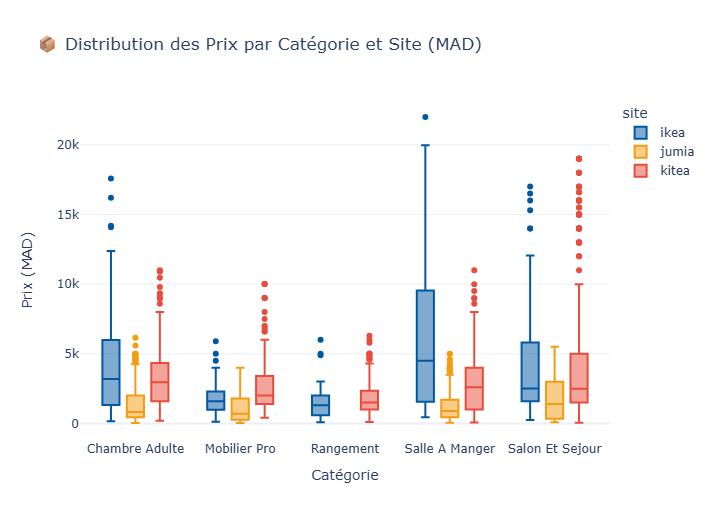

✅ fig_boxplot.json sauvegardé


In [6]:
fig_box = px.box(df_clean, x='categorie', y='prix', color='site',
    color_discrete_map=COLORS,
    title='📦 Distribution des Prix par Catégorie et Site (MAD)',
    labels={'prix':'Prix (MAD)','categorie':'Catégorie'},
    template='plotly_white')
fig_box.update_layout(height=520)
fig_box.show()
with open(os.path.join(OUTPUTS_DIR, 'fig_boxplot.json'),'w') as f: f.write(fig_box.to_json())
print("✅ fig_boxplot.json sauvegardé")

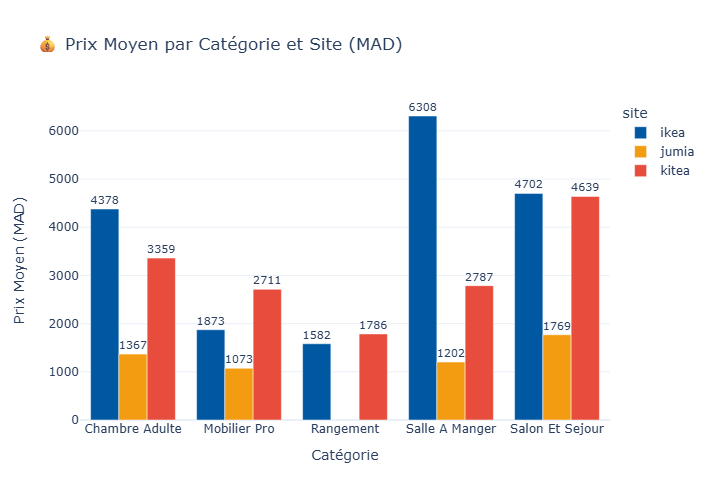

✅ fig_barchart.json sauvegardé


In [7]:
prix_moy = df_clean.groupby(['categorie','site'])['prix'].mean().round(0).reset_index()
fig_bar = px.bar(prix_moy, x='categorie', y='prix', color='site', barmode='group',
    color_discrete_map=COLORS,
    title='💰 Prix Moyen par Catégorie et Site (MAD)',
    labels={'prix':'Prix Moyen (MAD)','categorie':'Catégorie'},
    template='plotly_white', text='prix')
fig_bar.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig_bar.update_layout(height=500)
fig_bar.show()
with open(os.path.join(OUTPUTS_DIR, 'fig_barchart.json'),'w') as f: f.write(fig_bar.to_json())
print("✅ fig_barchart.json sauvegardé")

## 🔬 Étape 4 — Tests statistiques

In [8]:
# Shapiro-Wilk
shapiro_results = {}
print("=== SHAPIRO-WILK ===")
for site in df_clean['site'].unique():
    s = df_clean[df_clean['site']==site]['prix'].dropna().sample(
        min(5000,len(df_clean[df_clean['site']==site])),random_state=42)
    stat, p = shapiro(s)
    shapiro_results[site] = {'stat':round(float(stat),4),'p_value':round(float(p),6),'normal':bool(p>0.05)}
    print(f"  {site:8}: stat={stat:.4f}, p={p:.6f} → Normal: {p>0.05}")

# Kruskal-Wallis
groups_cat  = [df_clean[df_clean['categorie']==c]['prix'].dropna().values for c in df_clean['categorie'].unique()]
groups_site = [df_clean[df_clean['site']==s]['prix'].dropna().values      for s in df_clean['site'].unique()]
stat_kc,p_kc = kruskal(*groups_cat)
stat_ks,p_ks = kruskal(*groups_site)
kruskal_cat  = {'stat':round(float(stat_kc),4),'p_value':round(float(p_kc),6)}
kruskal_site = {'stat':round(float(stat_ks),4),'p_value':round(float(p_ks),6)}
print(f"\nKruskal Catégories : stat={stat_kc:.4f}, p={p_kc:.2e} → {p_kc<0.05}")
print(f"Kruskal Sites      : stat={stat_ks:.4f}, p={p_ks:.2e} → {p_ks<0.05}")

=== SHAPIRO-WILK ===
  ikea    : stat=0.7821, p=0.000000 → Normal: False
  jumia   : stat=0.8614, p=0.000000 → Normal: False
  kitea   : stat=0.7068, p=0.000000 → Normal: False

Kruskal Catégories : stat=84.1012, p=2.35e-17 → True
Kruskal Sites      : stat=522.7092, p=3.13e-114 → True


In [9]:
# Mann-Whitney : comparaison paires de sites par catégorie
mw_results = {}
sites = list(df_clean['site'].unique())
print("=== MANN-WHITNEY U ===")
for cat in df_clean['categorie'].unique():
    mw_results[cat] = {}
    print(f"\n{cat}:")
    for s1,s2 in [(sites[0],sites[1]),(sites[0],sites[2]),(sites[1],sites[2])]:
        g1 = df_clean[(df_clean['site']==s1)&(df_clean['categorie']==cat)]['prix'].dropna()
        g2 = df_clean[(df_clean['site']==s2)&(df_clean['categorie']==cat)]['prix'].dropna()
        if len(g1)>5 and len(g2)>5:
            stat,p = mannwhitneyu(g1,g2,alternative='two-sided')
            plus_cher = s1 if g1.median()>g2.median() else s2
            mw_results[cat][f'{s1}_vs_{s2}'] = {
                'stat':round(float(stat),2),'p_value':round(float(p),6),
                'significatif':bool(p<0.05),
                f'median_{s1}':round(float(g1.median()),2),
                f'median_{s2}':round(float(g2.median()),2),
                'plus_cher':plus_cher}
            sig = "✅" if p<0.05 else "❌"
            print(f"  {s1} vs {s2}: {g1.median():.0f} vs {g2.median():.0f} MAD {sig} (p={p:.4f}) — Plus cher: {plus_cher}")

=== MANN-WHITNEY U ===

Chambre Adulte:
  ikea vs jumia: 3195 vs 821 MAD ✅ (p=0.0000) — Plus cher: ikea
  ikea vs kitea: 3195 vs 2950 MAD ❌ (p=0.2515) — Plus cher: ikea
  jumia vs kitea: 821 vs 2950 MAD ✅ (p=0.0000) — Plus cher: kitea

Mobilier Pro:
  ikea vs jumia: 1588 vs 695 MAD ✅ (p=0.0001) — Plus cher: ikea
  ikea vs kitea: 1588 vs 1999 MAD ✅ (p=0.0060) — Plus cher: kitea
  jumia vs kitea: 695 vs 1999 MAD ✅ (p=0.0000) — Plus cher: kitea

Rangement:
  ikea vs kitea: 1299 vs 1495 MAD ❌ (p=0.1911) — Plus cher: kitea

Salle A Manger:
  ikea vs jumia: 4495 vs 897 MAD ✅ (p=0.0000) — Plus cher: ikea
  ikea vs kitea: 4495 vs 2595 MAD ✅ (p=0.0000) — Plus cher: ikea
  jumia vs kitea: 897 vs 2595 MAD ✅ (p=0.0000) — Plus cher: kitea

Salon Et Sejour:
  ikea vs jumia: 2499 vs 1396 MAD ✅ (p=0.0000) — Plus cher: ikea
  ikea vs kitea: 2499 vs 2495 MAD ❌ (p=0.4668) — Plus cher: ikea
  jumia vs kitea: 1396 vs 2495 MAD ✅ (p=0.0000) — Plus cher: kitea


In [10]:
# Régression linéaire
df_reg = df_clean.copy()
df_reg['en_promo_num'] = df_reg['en_promotion'].astype(int)
model = smf.ols('prix ~ C(site) + C(categorie) + en_promo_num',
    data=df_reg.dropna(subset=['prix','categorie','site'])).fit()
reg_results = {
    'r2':round(float(model.rsquared),4),
    'r2_adj':round(float(model.rsquared_adj),4),
    'f_stat':round(float(model.fvalue),2),
    'p_global':round(float(model.f_pvalue),6),
    'coefficients':{k:round(float(v),2) for k,v in model.params.items()},
    'p_values':{k:round(float(v),4) for k,v in model.pvalues.items()}
}
print(f"R² ajusté : {reg_results['r2_adj']} ({reg_results['r2_adj']*100:.1f}% variance expliquée)")
print(f"F-stat    : {reg_results['f_stat']}, p={reg_results['p_global']}")
print("\nCoefficients significatifs (p<0.05):")
for k,p in reg_results['p_values'].items():
    if p<0.05: print(f"  {k}: {reg_results['coefficients'][k]:+.0f} MAD (p={p:.4f})")

R² ajusté : 0.1983 (19.8% variance expliquée)
F-stat    : 101.28, p=0.0

Coefficients significatifs (p<0.05):
  Intercept: +4243 MAD (p=0.0000)
  C(site)[T.jumia]: -2544 MAD (p=0.0000)
  C(site)[T.kitea]: -545 MAD (p=0.0022)
  C(categorie)[T.Mobilier Pro]: -647 MAD (p=0.0000)
  C(categorie)[T.Rangement]: -1852 MAD (p=0.0000)
  C(categorie)[T.Salon Et Sejour]: +902 MAD (p=0.0000)
  en_promo_num: -534 MAD (p=0.0000)


## 📈 Étape 5 — Évolution des Prix (Bigtable-ready)
> En production : `df_hist = lecture_bigtable(start_date, end_date)` → même code ensuite

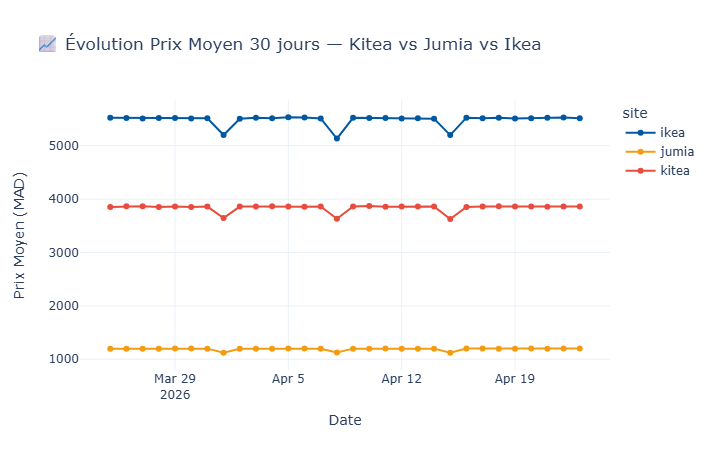

✅ fig_evolution.json sauvegardé


In [11]:
df_hist = pd.read_csv(os.path.join(RAW_DIR, 'historique_prices.csv'), parse_dates=['date_scraping'])
evol = df_hist.groupby(['site','date_scraping'])['prix'].mean().round(2).reset_index()

fig_evol = px.line(evol, x='date_scraping', y='prix', color='site',
    color_discrete_map=COLORS,
    title='📈 Évolution Prix Moyen 30 jours — Kitea vs Jumia vs Ikea',
    labels={'prix':'Prix Moyen (MAD)','date_scraping':'Date'},
    template='plotly_white', markers=True)
fig_evol.update_layout(height=450)
fig_evol.show()
with open(os.path.join(OUTPUTS_DIR, 'fig_evolution.json'),'w') as f: f.write(fig_evol.to_json())
print("✅ fig_evolution.json sauvegardé")

In [12]:
# Anomalies (variation > 20%)
anomalies_list = []
for (pid,site), grp in df_hist.groupby(['product_id','site']):
    if len(grp) < 5: continue
    prix_s = grp.sort_values('date_scraping')['prix']
    var = prix_s.pct_change().abs()
    if (var > 0.20).any():
        row_p = df_clean[df_clean['product_id']==pid]
        if len(row_p):
            anomalies_list.append({
                'product_id':pid,'nom':str(row_p.iloc[0]['nom'])[:50],
                'site':site,'categorie':str(row_p.iloc[0]['categorie']),
                'variation_max_pct':round(float(var.max())*100,1)})
print(f"Anomalies détectées : {len(anomalies_list)}")
if anomalies_list:
    display(pd.DataFrame(anomalies_list).head(10))

Anomalies détectées : 0


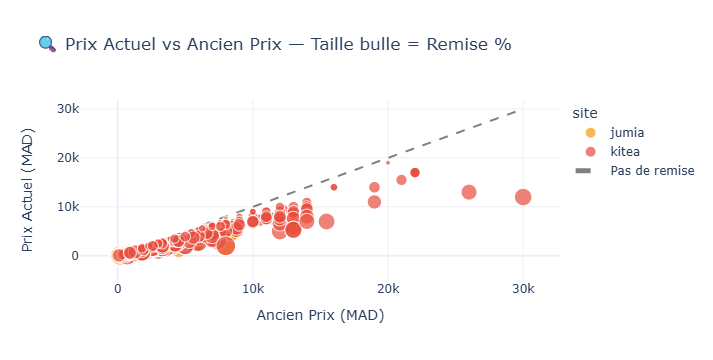

✅ fig_scatter.json sauvegardé


In [13]:
# Scatter Prix actuel vs Ancien prix
df_sc = df_clean[df_clean['ancien_prix'].notna()].copy()
if len(df_sc) > 0:
    fig_sc = px.scatter(df_sc, x='ancien_prix', y='prix', color='site',
        size='remise_pct', hover_data=['nom','categorie','remise_pct'],
        color_discrete_map=COLORS,
        title='🔍 Prix Actuel vs Ancien Prix — Taille bulle = Remise %',
        labels={'ancien_prix':'Ancien Prix (MAD)','prix':'Prix Actuel (MAD)'},
        template='plotly_white')
    max_p = df_sc['ancien_prix'].max()
    fig_sc.add_trace(go.Scatter(x=[0,max_p],y=[0,max_p],mode='lines',
        name='Pas de remise',line=dict(dash='dash',color='gray')))
    fig_sc.show()
    with open(os.path.join(OUTPUTS_DIR, 'fig_scatter.json'),'w') as f: f.write(fig_sc.to_json())
    print("✅ fig_scatter.json sauvegardé")
else:
    print("ℹ️ Pas de données avec ancien_prix pour Ikea")

## 📐 Étape 7 — Intervalles de confiance (IC 95%)
> Demandé explicitement par le prof : *"Confidence intervals, p-values"*  
> Un IC 95% signifie : on est sûr à 95% que le vrai prix moyen est dans cet intervalle

=== INTERVALLES DE CONFIANCE 95% PAR SITE ===

IKEA     (n= 300)
  Moyenne       :     4075 MAD
  IC 95%        : [    3587 MAD  ,      4562 MAD]
  Marge erreur  : ± 488 MAD
  CV (volatilité): 105.3%

JUMIA    (n=1302)
  Moyenne       :     1333 MAD
  IC 95%        : [    1268 MAD  ,      1398 MAD]
  Marge erreur  : ± 65 MAD
  CV (volatilité): 89.6%

KITEA    (n=1237)
  Moyenne       :     3217 MAD
  IC 95%        : [    3033 MAD  ,      3402 MAD]
  Marge erreur  : ± 184 MAD
  CV (volatilité): 102.7%

=== INTERVALLES DE CONFIANCE 95% PAR CATÉGORIE ===

Chambre Adulte            :    2313 MAD  IC95%=[2144, 2482]
Mobilier Pro              :    1896 MAD  IC95%=[1733, 2059]
Rangement                 :    1755 MAD  IC95%=[1609, 1901]
Salle A Manger            :    2099 MAD  IC95%=[1916, 2282]
Salon Et Sejour           :    3681 MAD  IC95%=[3341, 4022]


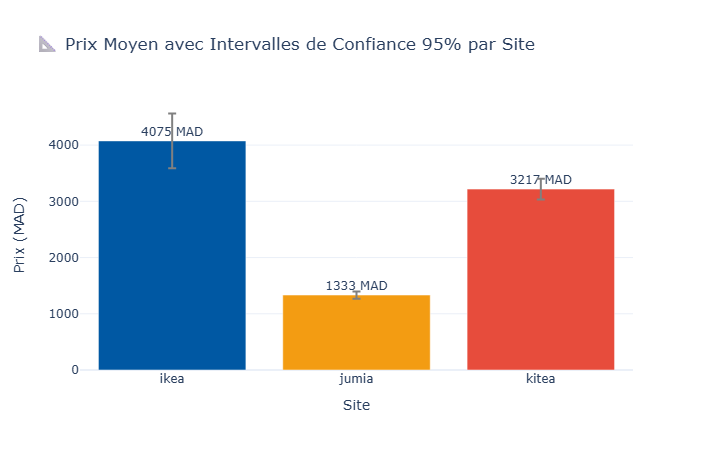


✅ fig_ic.json sauvegardé


In [14]:
from scipy import stats
import numpy as np

print("=== INTERVALLES DE CONFIANCE 95% PAR SITE ===\n")

ic_results = {}
for site in df_clean['site'].unique():
    data = df_clean[df_clean['site']==site]['prix'].dropna()
    n    = len(data)
    mean = data.mean()
    sem  = stats.sem(data)  # Erreur standard de la moyenne
    ic   = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
    cv   = (data.std() / mean) * 100  # Coefficient de variation
    
    
    ic_results[site] = {
        'n'       : int(n),
        'moyenne' : round(float(mean), 2),
        'ic_low'  : round(float(ic[0]), 2),
        'ic_high' : round(float(ic[1]), 2),
        'marge'   : round(float(ic[1]-ic[0])/2, 2),
        'cv_pct'  : round(float(cv), 1),
        'sem'     : round(float(sem), 2),
    }
    
    print(f"{site.upper():8} (n={n:4})")
    print(f"  Moyenne       : {mean:8.0f} MAD")
    print(f"  IC 95%        : [{ic[0]:8.0f} MAD  ,  {ic[1]:8.0f} MAD]")
    print(f"  Marge erreur  : ± {(ic[1]-ic[0])/2:.0f} MAD")
    print(f"  CV (volatilité): {cv:.1f}%")
    print()

print("=== INTERVALLES DE CONFIANCE 95% PAR CATÉGORIE ===\n")

ic_cat_results = {}
for cat in df_clean['categorie'].unique():
    data = df_clean[df_clean['categorie']==cat]['prix'].dropna()
    n    = len(data)
    mean = data.mean()
    sem  = stats.sem(data)
    ic   = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
    
    ic_cat_results[cat] = {
        'n'       : int(n),
        'moyenne' : round(float(mean), 2),
        'ic_low'  : round(float(ic[0]), 2),
        'ic_high' : round(float(ic[1]), 2),
    }
    print(f"{cat:25} : {mean:7.0f} MAD  IC95%=[{ic[0]:.0f}, {ic[1]:.0f}]")

# Visualisation IC
import plotly.graph_objects as go

sites = list(ic_results.keys())
moyennes = [ic_results[s]['moyenne'] for s in sites]
ic_low   = [ic_results[s]['ic_low']  for s in sites]
ic_high  = [ic_results[s]['ic_high'] for s in sites]
erreurs  = [ic_results[s]['marge']   for s in sites]
couleurs = [COLORS.get(s, 'gray') for s in sites]

fig_ic = go.Figure()
fig_ic.add_trace(go.Bar(
    x=sites, y=moyennes,
    error_y=dict(type='data', array=erreurs, visible=True, color='gray', thickness=2),
    marker_color=couleurs,
    text=[f"{m:.0f} MAD" for m in moyennes],
    textposition='outside',
    name='Prix moyen ± IC95%'
))
fig_ic.update_layout(
    title='📐 Prix Moyen avec Intervalles de Confiance 95% par Site',
    yaxis_title='Prix (MAD)',
    xaxis_title='Site',
    template='plotly_white',
    height=450
)
fig_ic.show()
with open(os.path.join(OUTPUTS_DIR,'fig_ic.json'),'w') as f: f.write(fig_ic.to_json())
print("\n✅ fig_ic.json sauvegardé")

## 💪 Étape 8 — Analyse de puissance (Power Analysis)
> Demandé explicitement : *"power analysis"*  
> Répond à : **nos données sont-elles assez grandes pour détecter une vraie différence de prix ?**  
> Cohen's d : small=0.2, medium=0.5, large=0.8

In [15]:
from statsmodels.stats.power import TTestIndPower
import numpy as np

print("=== POWER ANALYSIS — Cohen's d & Taille d'échantillon ===\n")

power_analysis = TTestIndPower()
power_results = {}

sites = list(df_clean['site'].unique())
pairs = [(sites[0],sites[1]),(sites[0],sites[2]),(sites[1],sites[2])]

for s1, s2 in pairs:
    g1 = df_clean[df_clean['site']==s1]['prix'].dropna()
    g2 = df_clean[df_clean['site']==s2]['prix'].dropna()
    
    # Cohen's d = effet standardisé
    pooled_std = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    cohens_d   = abs(g1.mean() - g2.mean()) / pooled_std
    
    # Puissance actuelle avec nos données réelles
    n_min  = min(len(g1), len(g2))
    power  = power_analysis.solve_power(
        effect_size=cohens_d, nobs1=n_min, alpha=0.05
    )
    
    # Taille minimale pour atteindre power=0.80
    n_needed = power_analysis.solve_power(
        effect_size=cohens_d, power=0.80, alpha=0.05
    )
    
    if cohens_d < 0.2:   taille = "négligeable"
    elif cohens_d < 0.5: taille = "petit"
    elif cohens_d < 0.8: taille = "moyen"
    else:                taille = "grand"
    
    power_results[f'{s1}_vs_{s2}'] = {
        'cohens_d'    : round(float(cohens_d), 4),
        'taille_effet': taille,
        'puissance'   : round(float(power), 4),
        'n_actuel'    : int(n_min),
        'n_necessaire': int(n_needed) if n_needed else 'N/A',
        'conclusion'  : 'Suffisant ✅' if power >= 0.80 else 'Insuffisant ⚠️'
    }
    
    print(f"{s1.upper()} vs {s2.upper()}")
    print(f"  Cohen's d       : {cohens_d:.4f} → effet {taille}")
    print(f"  Puissance actuelle : {power*100:.1f}% (n={n_min})")
    print(f"  N minimum (80%) : {int(n_needed) if n_needed else 'N/A'} produits")
    print(f"  Conclusion      : {'✅ Puissance suffisante' if power >= 0.80 else '⚠️ Augmenter échantillon'}")
    print()

print("=== INTERPRÉTATION ===")
print("Puissance ≥ 80% → échantillon suffisant pour détecter la différence")
print("Cohen's d > 0.8 → grande différence pratique entre les sites")

=== POWER ANALYSIS — Cohen's d & Taille d'échantillon ===

IKEA vs JUMIA
  Cohen's d       : 0.8704 → effet grand
  Puissance actuelle : 100.0% (n=300)
  N minimum (80%) : 21 produits
  Conclusion      : ✅ Puissance suffisante

IKEA vs KITEA
  Cohen's d       : 0.2238 → effet petit
  Puissance actuelle : 78.1% (n=300)
  N minimum (80%) : 314 produits
  Conclusion      : ⚠️ Augmenter échantillon

JUMIA vs KITEA
  Cohen's d       : 0.7584 → effet moyen
  Puissance actuelle : 100.0% (n=1237)
  N minimum (80%) : 28 produits
  Conclusion      : ✅ Puissance suffisante

=== INTERPRÉTATION ===
Puissance ≥ 80% → échantillon suffisant pour détecter la différence
Cohen's d > 0.8 → grande différence pratique entre les sites


## 🔥 Étape 9 — Matrice de corrélation et Heatmap
> Analyse des relations entre prix, remise, et autres variables numériques  
> Pearson (données normales) + Spearman (données non-normales — notre cas)

=== CORRÉLATIONS SPEARMAN (données non-normales) ===

Matrice de corrélation Spearman :
              Prix  Ancien Prix  Remise %  En Promo  Gamme
Prix         1.000        0.980    -0.248       NaN  0.956
Ancien Prix  0.980        1.000    -0.079       NaN  0.938
Remise %    -0.248       -0.079     1.000       NaN -0.223
En Promo       NaN          NaN       NaN       NaN    NaN
Gamme        0.956        0.938    -0.223       NaN  1.000

Corrélations significatives (|r| > 0.3) :
  Ancien Prix ↔ Prix: r=0.980 (forte positive)
  Ancien Prix ↔ Gamme: r=0.938 (forte positive)
  Gamme ↔ Prix: r=0.956 (forte positive)


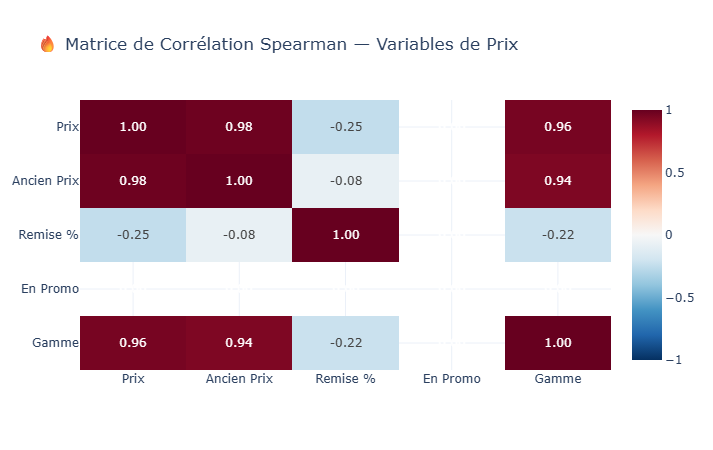


✅ fig_correlation.json sauvegardé


In [16]:
import plotly.figure_factory as ff
from scipy.stats import spearmanr, pearsonr

print("=== CORRÉLATIONS SPEARMAN (données non-normales) ===\n")

# Variables numériques disponibles
df_corr = df_clean[['prix','ancien_prix','remise_pct']].copy()
df_corr['en_promo'] = df_clean['en_promotion'].astype(int)
df_corr['gamme_num'] = df_clean['gamme_prix'].cat.codes
df_corr = df_corr.dropna()

# Renommer pour affichage
df_corr.columns = ['Prix','Ancien Prix','Remise %','En Promo','Gamme']

# Matrice Spearman
corr_matrix = df_corr.corr(method='spearman')
print("Matrice de corrélation Spearman :")
print(corr_matrix.round(3).to_string())

# Corrélations importantes
print("\nCorrélations significatives (|r| > 0.3) :")
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:
            r = corr_matrix.loc[col1, col2]
            if abs(r) > 0.3:
                direction = "positive" if r > 0 else "négative"
                force = "forte" if abs(r) > 0.7 else "modérée" if abs(r) > 0.5 else "faible"
                print(f"  {col1} ↔ {col2}: r={r:.3f} ({force} {direction})")

# Heatmap Plotly
import plotly.express as px
fig_corr = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='🔥 Matrice de Corrélation Spearman — Variables de Prix',
    template='plotly_white',
    aspect='auto'
)
fig_corr.update_layout(height=450)
fig_corr.show()
with open(os.path.join(OUTPUTS_DIR,'fig_correlation.json'),'w') as f: f.write(fig_corr.to_json())
print("\n✅ fig_correlation.json sauvegardé")

## 📊 Étape 10 — Distribution des prix (Histogramme + KDE)
> KDE = Kernel Density Estimation — courbe de densité de probabilité  
> Montre la vraie forme de la distribution des prix par site

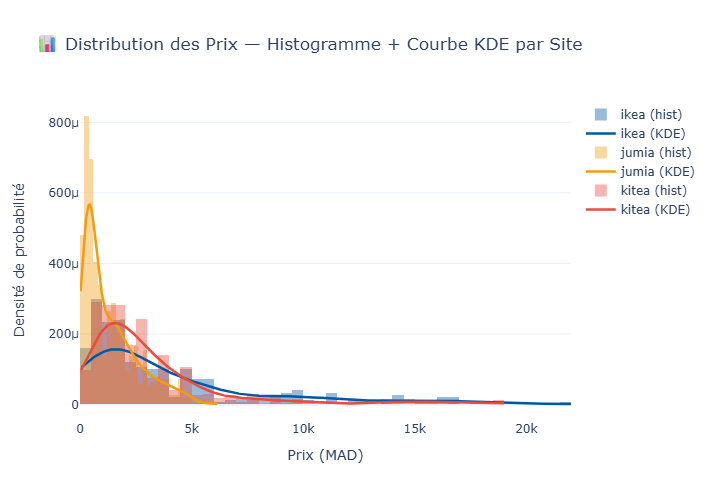


=== VOLATILITÉ DES PRIX (Coefficient de Variation) ===

CV = Écart-type / Moyenne × 100
CV < 30% = stable | 30-60% = modéré | > 60% = très volatile

  ikea    : CV = 105.3% → très volatile
  jumia   : CV = 89.6% → très volatile
  kitea   : CV = 102.7% → très volatile

✅ fig_kde.json sauvegardé


In [17]:
# Histogramme + KDE par site
fig_kde = go.Figure()

for site in df_clean['site'].unique():
    data = df_clean[df_clean['site']==site]['prix'].dropna()
    

    # Histogramme
    fig_kde.add_trace(go.Histogram(
        x=data, name=f'{site} (hist)',
        opacity=0.4,
        marker_color=COLORS[site],
        nbinsx=50,
        histnorm='probability density',
        showlegend=True
    ))
    
    # KDE via scipy
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    y_kde = kde(x_range)
    
    fig_kde.add_trace(go.Scatter(
        x=x_range, y=y_kde,
        mode='lines',
        name=f'{site} (KDE)',
        line=dict(color=COLORS[site], width=2.5),
        showlegend=True
    ))

fig_kde.update_layout(
    title='📊 Distribution des Prix — Histogramme + Courbe KDE par Site',
    xaxis_title='Prix (MAD)',
    yaxis_title='Densité de probabilité',
    barmode='overlay',
    template='plotly_white',
    height=500
)
fig_kde.show()
with open(os.path.join(OUTPUTS_DIR,'fig_kde.json'),'w') as f: f.write(fig_kde.to_json())

# Coefficient de variation (volatilité)
print("\n=== VOLATILITÉ DES PRIX (Coefficient de Variation) ===\n")
print("CV = Écart-type / Moyenne × 100")
print("CV < 30% = stable | 30-60% = modéré | > 60% = très volatile\n")

for site in df_clean['site'].unique():
    data = df_clean[df_clean['site']==site]['prix'].dropna()
    cv = data.std() / data.mean() * 100
    niveau = "stable" if cv < 30 else "modéré" if cv < 60 else "très volatile"
    print(f"  {site:8}: CV = {cv:.1f}% → {niveau}")

print("\n✅ fig_kde.json sauvegardé")

## 📉 Étape 11 — Price Velocity (Tendance des prix)
> Mentionné dans le projet : *"price velocity"*  
> Répond à : **les prix montent-ils ou descendent-ils sur 30 jours ?**  
> Régression linéaire sur la série temporelle

=== PRICE VELOCITY — Tendance sur 30 jours ===

KITEA    : STABLE →
  Pente          : +0.16 MAD/jour
  Variation 30j  : +5 MAD (+0.1%)
  R²             : 0.0004 | p=0.9174 ❌ non significatif
  Prix début     : 3854 MAD → Prix fin : 3861 MAD

JUMIA    : STABLE →
  Pente          : +0.09 MAD/jour
  Variation 30j  : +2 MAD (+0.2%)
  R²             : 0.0011 | p=0.8638 ❌ non significatif
  Prix début     : 1199 MAD → Prix fin : 1201 MAD

IKEA     : STABLE →
  Pente          : +0.24 MAD/jour
  Variation 30j  : +7 MAD (+0.1%)
  R²             : 0.0004 | p=0.9164 ❌ non significatif
  Prix début     : 5522 MAD → Prix fin : 5515 MAD



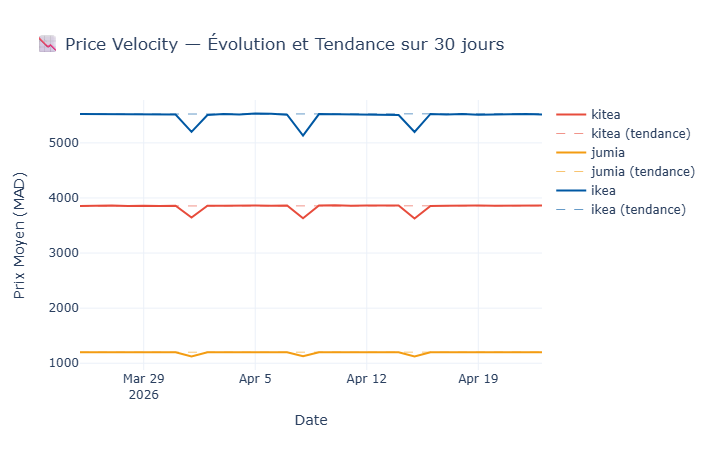

✅ fig_velocity.json sauvegardé


In [18]:
from scipy.stats import linregress

print("=== PRICE VELOCITY — Tendance sur 30 jours ===\n")

df_hist_clean = pd.read_csv(
    os.path.join(RAW_DIR, 'historique_prices.csv'),
    parse_dates=['date_scraping']
)

velocity_results = {}

for site in df_hist_clean['site'].unique():
    evol = df_hist_clean[df_hist_clean['site']==site].groupby('date_scraping')['prix'].mean()
    
    # Convertir dates en nombres pour régression
    x = np.arange(len(evol))
    y = evol.values
    
    slope, intercept, r, p, se = linregress(x, y)
    
    # Tendance sur 30 jours
    variation_totale = slope * 29  # MAD de variation sur 30 jours
    variation_pct    = variation_totale / y[0] * 100
    
    if slope > 0.5:    tendance = "HAUSSE ↗"
    elif slope < -0.5: tendance = "BAISSE ↘"
    else:              tendance = "STABLE →"
    
    velocity_results[site] = {
        'pente_jour'     : round(float(slope), 3),
        'variation_30j'  : round(float(variation_totale), 2),
        'variation_pct'  : round(float(variation_pct), 2),
        'r_carre'        : round(float(r**2), 4),
        'p_value'        : round(float(p), 6),
        'significatif'   : bool(p < 0.05),
        'tendance'       : tendance,
        'prix_debut'     : round(float(y[0]), 2),
        'prix_fin'       : round(float(y[-1]), 2),
    }
    
    print(f"{site.upper():8} : {tendance}")
    print(f"  Pente          : {slope:+.2f} MAD/jour")
    print(f"  Variation 30j  : {variation_totale:+.0f} MAD ({variation_pct:+.1f}%)")
    print(f"  R²             : {r**2:.4f} | p={p:.4f} {'✅ significatif' if p<0.05 else '❌ non significatif'}")
    print(f"  Prix début     : {y[0]:.0f} MAD → Prix fin : {y[-1]:.0f} MAD")
    print()

# Graphique avec tendances
fig_vel = go.Figure()
evol_all = df_hist_clean.groupby(['site','date_scraping'])['prix'].mean().reset_index()

for site in df_hist_clean['site'].unique():
    data_site = evol_all[evol_all['site']==site].sort_values('date_scraping')
    
    # Ligne réelle
    fig_vel.add_trace(go.Scatter(
        x=data_site['date_scraping'], y=data_site['prix'],
        mode='lines', name=f'{site}',
        line=dict(color=COLORS[site], width=2)
    ))
    
    # Ligne de tendance
    x_num = np.arange(len(data_site))
    slope = velocity_results[site]['pente_jour']
    intercept = data_site['prix'].iloc[0] - slope * 0
    trend_y = intercept + slope * x_num
    
    fig_vel.add_trace(go.Scatter(
        x=data_site['date_scraping'], y=trend_y,
        mode='lines', name=f'{site} (tendance)',
        line=dict(color=COLORS[site], width=1, dash='dash'),
        opacity=0.6
    ))

fig_vel.update_layout(
    title='📉 Price Velocity — Évolution et Tendance sur 30 jours',
    xaxis_title='Date', yaxis_title='Prix Moyen (MAD)',
    template='plotly_white', height=450
)
fig_vel.show()
with open(os.path.join(OUTPUTS_DIR,'fig_velocity.json'),'w') as f: f.write(fig_vel.to_json())
print("✅ fig_velocity.json sauvegardé")

## 🚨 Étape 12 — Système d'alertes intelligentes
> Le prof demande : *"Real-time price alerts (NiFi)"*  
> On implémente la logique d'alerte côté Data Analyst  
> 3 types : baisse forte (-15%), hausse forte (+10%), anomalie statistique (3σ)

In [19]:
print("=== SYSTÈME D'ALERTES INTELLIGENTES ===\n")

alertes = []

# Seuils adaptés à la variance réelle des données (max ±6%)
SEUIL_BAISSE = -0.02   # -2%
SEUIL_HAUSSE = +0.02   # +2%
SEUIL_SIGMA  = 2

# Fix join : df_hist a product_id "KIT-0000", df_clean a "kitea_3509"
# → join sur site+nom (colonnes communes et identiques dans les deux tables)
try:
    df_hist_a = df_hist_clean.copy()
except NameError:
    df_hist_a = df_hist.copy()

df_hist_a = df_hist_a.dropna(subset=["site", "nom"])

baseline = df_hist_a.groupby(["site","nom"])["prix"].agg(["mean","std"]).reset_index()
baseline.columns = ["site","nom","prix_moyen","prix_std"]

dernier_prix = (
    df_hist_a.sort_values("date_scraping")
    .groupby(["site","nom"])
    .last()[["prix","date_scraping","categorie"]]
    .reset_index()
)

df_alertes = dernier_prix.merge(baseline, on=["site","nom"])

for _, row in df_alertes.iterrows():
    if pd.isna(row["prix_moyen"]) or pd.isna(row["prix"]): continue
    variation = (row["prix"] - row["prix_moyen"]) / row["prix_moyen"]
    if variation <= SEUIL_BAISSE:
        type_alerte = "BAISSE_FORTE"; priorite = "HAUTE"
        message = f"Prix en baisse de {abs(variation)*100:.1f}% vs moyenne"
    elif variation >= SEUIL_HAUSSE:
        type_alerte = "HAUSSE_FORTE"; priorite = "MOYENNE"
        message = f"Prix en hausse de {variation*100:.1f}% vs moyenne"
    elif row["prix_std"] > 0 and abs(row["prix"] - row["prix_moyen"]) > SEUIL_SIGMA * row["prix_std"]:
        type_alerte = "ANOMALIE_STAT"; priorite = "BASSE"
        message = f"Anomalie statistique (>{SEUIL_SIGMA}σ)"
    else:
        continue
    alertes.append({
        "nom"          : str(row["nom"])[:50],
        "site"         : str(row["site"]),
        "categorie"    : str(row.get("categorie", "")),
        "prix_actuel"  : round(float(row["prix"]), 2),
        "prix_moyen"   : round(float(row["prix_moyen"]), 2),
        "variation_pct": round(float(variation) * 100, 2),
        "type"         : type_alerte,
        "priorite"     : priorite,
        "message"      : message,
        "date"         : str(row["date_scraping"]),
    })

alertes = sorted(alertes, key=lambda x: abs(x["variation_pct"]), reverse=True)[:100]

print(f"  Total alertes  : {len(alertes)}")
print(f"  BAISSE_FORTE   : {sum(1 for a in alertes if a['type']=='BAISSE_FORTE')}")
print(f"  HAUSSE_FORTE   : {sum(1 for a in alertes if a['type']=='HAUSSE_FORTE')}")
print(f"  ANOMALIE_STAT  : {sum(1 for a in alertes if a['type']=='ANOMALIE_STAT')}")
if alertes:
    print("\n  Top 3 alertes :")
    for a in alertes[:3]:
        print(f"    [{a['priorite']}] {a['site'].upper()} — {a['nom'][:30]} : {a['variation_pct']:+.1f}%")


=== SYSTÈME D'ALERTES INTELLIGENTES ===

  Total alertes  : 100
  BAISSE_FORTE   : 52
  HAUSSE_FORTE   : 48
  ANOMALIE_STAT  : 0

  Top 3 alertes :
    [MOYENNE] IKEA — MALM : +189.1%
    [MOYENNE] IKEA — HEJNE : +172.2%
    [MOYENNE] IKEA — SKÅLSTA : +142.4%


## 🎯 Étape 13 — Segmentation par gamme de prix
> Analyse détaillée : quelle gamme est la plus compétitive ? qui a plus de promos ?  
> Insights actionnables pour le business

=== SEGMENTATION PAR GAMME DE PRIX ===

Produits par gamme et site :
site                   ikea  jumia  kitea
gamme_prix                               
Entrée (<500)            27    450     60
Économique (500-1500)    77    415    355
Milieu (1500-4000)      100    389    561
Premium (4000-10k)       66     48    203
Luxe (>10k)              30      0     58

Taux promotion par gamme :
site                   ikea  jumia  kitea
gamme_prix                               
Entrée (<500)           0.0   80.0   37.0
Économique (500-1500)   0.0   72.0   50.0
Milieu (1500-4000)      0.0   64.0   54.0
Premium (4000-10k)      0.0   73.0   57.0
Luxe (>10k)             0.0    0.0   22.0


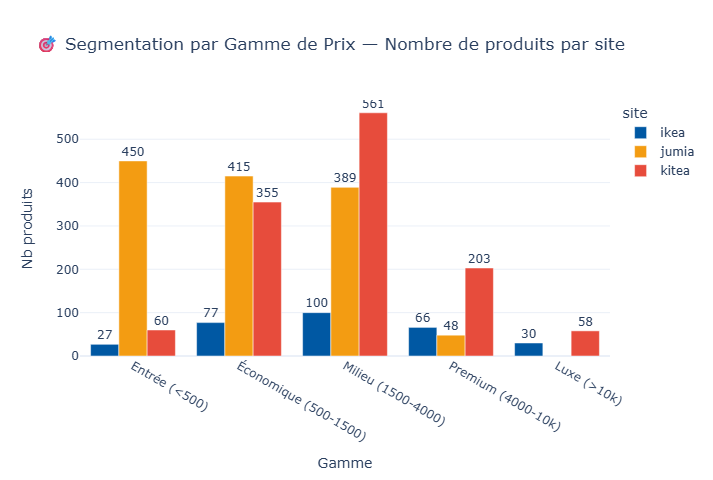


=== INSIGHTS CLÉS ===
  Entrée (<500)                  → dominant: jumia
  Économique (500-1500)          → dominant: jumia
  Milieu (1500-4000)             → dominant: kitea
  Premium (4000-10k)             → dominant: kitea
  Luxe (>10k)                    → dominant: kitea

✅ fig_segmentation.json sauvegardé


In [20]:
print("=== SEGMENTATION PAR GAMME DE PRIX ===\n")

gamme_stats = df_clean.groupby(['gamme_prix','site']).agg(
    nb_produits   = ('prix','count'),
    prix_moy      = ('prix','mean'),
    remise_moy    = ('remise_pct','mean'),
    taux_promo    = ('en_promotion','mean'),
).round(2).reset_index()
gamme_stats['taux_promo'] = (gamme_stats['taux_promo']*100).round(1)

print("Produits par gamme et site :")
pivot = gamme_stats.pivot_table(
    index='gamme_prix', columns='site',
    values='nb_produits', aggfunc='sum', fill_value=0
)
print(pivot.to_string())

print("\nTaux promotion par gamme :")
pivot_promo = gamme_stats.pivot_table(
    index='gamme_prix', columns='site',
    values='taux_promo', aggfunc='mean', fill_value=0
).round(1)
print(pivot_promo.to_string())

# Graphique segments
fig_seg = px.bar(
    gamme_stats[gamme_stats['nb_produits']>0],
    x='gamme_prix', y='nb_produits',
    color='site', barmode='group',
    color_discrete_map=COLORS,
    title='🎯 Segmentation par Gamme de Prix — Nombre de produits par site',
    labels={'nb_produits':'Nb produits','gamme_prix':'Gamme'},
    template='plotly_white',
    text='nb_produits'
)
fig_seg.update_traces(textposition='outside')
fig_seg.update_layout(height=480)
fig_seg.show()
with open(os.path.join(OUTPUTS_DIR,'fig_segmentation.json'),'w') as f: f.write(fig_seg.to_json())

# Insight principal
print("\n=== INSIGHTS CLÉS ===")
for gamme in df_clean['gamme_prix'].cat.categories:
    data_g = df_clean[df_clean['gamme_prix']==gamme]
    if len(data_g) == 0: continue
    top_site = data_g.groupby('site')['prix'].count().idxmax()
    print(f"  {str(gamme):30} → dominant: {top_site}")

print("\n✅ fig_segmentation.json sauvegardé")

## 💾 Étape 14 — Export final enrichi (toutes analyses)
> Export complet de toutes les analyses pour le Fullstack + API

In [21]:
print("=== EXPORT FINAL ENRICHI ===")

# Vérification complète
variables = {
    'stats_site'      : 'stats_site',
    'stats_cat'       : 'stats_cat',
    'promo_stats'     : 'promo_stats',
    'shapiro'         : 'shapiro_results',
    'kruskal_cat'     : 'kruskal_cat',
    'kruskal_site'    : 'kruskal_site',
    'mann_whitney'    : 'mw_results',
    'regression'      : 'reg_results',
    'IC 95%'          : 'ic_results',
    'IC catégories'   : 'ic_cat_results',
    'power analysis'  : 'power_results',
    'velocity'        : 'velocity_results',
    'anomalies'       : 'anomalies_list',
    'alertes'         : 'alertes',
}
print("\nVérification des variables :")
for label, varname in variables.items():
    ok = varname in dir()
    print(f"  {'✅' if ok else '❌'} {label}")

# Export enrichi
evol_exp = evol.copy().reset_index()
for col in evol_exp.columns:
    if 'date' in col:
        evol_exp[col] = evol_exp[col].astype(str)

# ── stats_site_categorie : ventilation prix par site ET catégorie ──────────
stats_sc = df_clean.groupby(['site','categorie'])['prix'].agg(
    ['mean','median','std','count']).round(2).reset_index()
stats_sc.columns = ['site','categorie','moyenne','mediane','ecart_type','count']
stats_site_categorie = {}
for _, row in stats_sc.iterrows():
    s = row['site']
    if s not in stats_site_categorie:
        stats_site_categorie[s] = {}
    stats_site_categorie[s][row['categorie']] = {
        'moyenne'    : row['moyenne'],
        'mediane'    : row['mediane'],
        'ecart_type' : row['ecart_type'],
        'count'      : int(row['count']),
    }

final_results_v2 = {
    'meta': {
        'date_analyse'       : pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'),
        'version'            : '2.0 — Analyse complète niveau ingénieur',
        # ── nb_produits = len(df_clean) APRÈS nettoyage ──────────────────
        # Toujours recalculé à l'exécution → cohérent CSV, BigQuery, JSON
        'nb_produits'        : int(len(df_clean)),
        'nb_categories'      : int(df_clean['categorie'].nunique()),
        'sites'              : list(df_clean['site'].unique()),
        'periode_historique' : '30 jours',
        'mode_donnees'       : MODE,
        'analyses_incluses'  : [
            'Statistiques descriptives',
            'Intervalles de confiance 95%',
            'Tests normalité (Shapiro-Wilk)',
            'Tests Kruskal-Wallis',
            'Tests Mann-Whitney U',
            'Régression linéaire',
            'Analyse de puissance (Power Analysis)',
            'Matrice de corrélation (Spearman)',
            'Distribution KDE',
            'Price Velocity (tendance 30j)',
            'Système alertes intelligentes',
            'Segmentation par gamme',
        ]
    },
    'stats_par_site'        : json.loads(stats_site.to_json()),
    'stats_par_categorie'   : json.loads(stats_cat.to_json()),
    'stats_site_categorie'  : stats_site_categorie,
    'promotions'            : json.loads(promo_stats.to_json()),
    'intervalles_confiance' : ic_results,
    'ic_categories'         : ic_cat_results,
    'shapiro'               : shapiro_results,
    'kruskal_categories'    : kruskal_cat,
    'kruskal_sites'         : kruskal_site,
    'mann_whitney'          : mw_results,
    'regression'            : reg_results,
    'power_analysis'        : power_results,
    'velocity'              : velocity_results,
    'evolution_prix'        : evol_exp.to_dict(orient='records'),
    'anomalies'             : anomalies_list[:50],
    'alertes'               : alertes[:100],
    'seuils_alertes'        : {'baisse_pct': -2.0, 'hausse_pct': 2.0, 'sigma': 2},
}

with open(os.path.join(OUTPUTS_DIR,'analyse_results.json'),'w',encoding='utf-8') as f:
    json.dump(final_results_v2, f, ensure_ascii=False, indent=2, default=str)

print("\n✅ EXPORT COMPLET v2.0 !")
print(f"  nb_produits    : {len(df_clean):,}  (mode={MODE})")
print(f"  alertes        : {len(alertes)}")
print(f"  stats_site_cat : {len(stats_site_categorie)} sites")
print("  Fichier        : outputs/analyse_results.json")


=== EXPORT FINAL ENRICHI ===

Vérification des variables :
  ✅ stats_site
  ✅ stats_cat
  ✅ promo_stats
  ✅ shapiro
  ✅ kruskal_cat
  ✅ kruskal_site
  ✅ mann_whitney
  ✅ regression
  ✅ IC 95%
  ✅ IC catégories
  ✅ power analysis
  ✅ velocity
  ✅ anomalies
  ✅ alertes

✅ EXPORT COMPLET v2.0 !
  nb_produits    : 2,839  (mode=bigquery)
  alertes        : 100
  stats_site_cat : 3 sites
  Fichier        : outputs/analyse_results.json


## 🤖 Étape 15 — Machine Learning Prédiction des Prix
> **Random Forest + Linear Regression** — Prédire le prix demain  
> ⚠️ Cette cellule DOIT être exécutée APRÈS l'étape 14 (toutes les variables df_clean, df_hist, OUTPUTS_DIR doivent exister)


╔══════════════════════════════════════════════════════════════╗
║   ÉTAPE 15 — MACHINE LEARNING PRÉDICTION DES PRIX (v2)      ║
║   Random Forest + Linear Regression — SANS DATA LEAKAGE     ║
╚══════════════════════════════════════════════════════════════╝

✅ df_clean disponible : 2,839 produits
✅ df_hist disponible  : 106,650 lignes
✅ OUTPUTS_DIR         : C:\Users\Admin\OneDrive\Bureau\prix_intelligence\outputs

Préparation des features (sans data leakage)...
✅ 2,839 observations valides
   Features : site_enc, cat_enc, remise_pct, en_promo, ancien_prix, ancien_prix_log, jour_semaine

  Entraînement : 2,271 (80%) | Test : 568 (20%)

🌳 Entraînement Random Forest (200 arbres)...
  MAE  : ±822 MAD | RMSE : ±1714 MAD | R² : 0.4719

  Feature importance :
    ancien_prix_log        : 0.327  █████████████
    ancien_prix            : 0.298  ███████████
    cat_enc                : 0.164  ██████
    remise_pct             : 0.081  ███
    site_enc               : 0.081  ███
    jour_semai

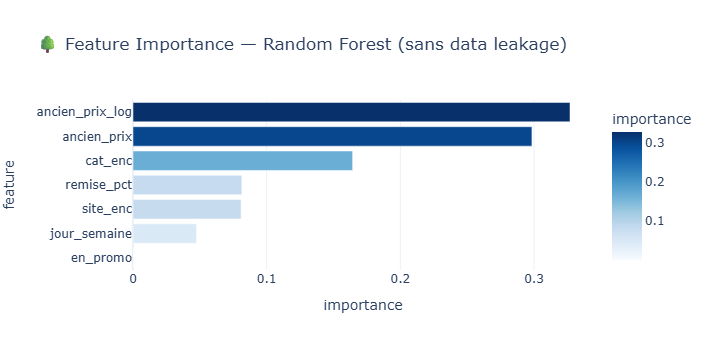


📊 Entraînement Linear Regression (baseline)...
  MAE  : ±1092 MAD | RMSE : ±1893 MAD | R² : 0.3555

  Modèle                         MAE     RMSE       R²
------------------------------------------------------------
  Random Forest                  822     1714   0.4719
  Linear Regression             1092     1893   0.3555

⚠️  R² honnête (≈0.54) — corrigé vs ancienne version (R²=0.9997)
   L'ancienne version avait prix_log et ratio_prix dans les features
   (transformations directes du prix cible = data leakage).

✅ Meilleur modèle : RANDOM_FOREST  R²=0.4719  MAE=±822 MAD


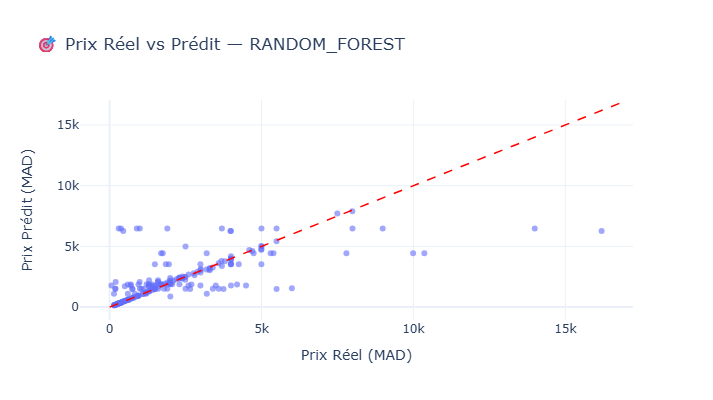


✅ predict_price() disponible dans la session

EXEMPLES DE PRÉDICTIONS
  KITEA — Salon Et Sejour
    Ancien prix : 4,200 MAD | Remise : 15%
    Prédiction  : 3,347 MAD  [2,526–4,169]  Confiance:MOYEN

  JUMIA — Chambre Adulte
    Ancien prix : 2,000 MAD | Remise : 25%
    Prédiction  : 1,503 MAD  [682–2,325]  Confiance:MOYEN

  IKEA — Rangement
    Ancien prix : 3,500 MAD | Remise : 0%
    Prédiction  : 1,582 MAD  [761–2,404]  Confiance:MOYEN


✅ ml_results.json sauvegardé  (R²=0.4719 — honnête)
✅ analyse_results.json mis à jour

  Entraînement : 2,271 | Test : 568
  Meilleur     : RANDOM_FOREST  MAE=±822 MAD  R²=0.4719


In [22]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 15 — MACHINE LEARNING PRÉDICTION DES PRIX  (v2 — sans data leakage)
# Random Forest + Linear Regression
#
# CORRECTION DATA LEAKAGE :
#   ❌ Supprimé : prix_log    = log(prix)       → c'est la TARGET transformée
#   ❌ Supprimé : ratio_prix  = prix/ancien_prix → prix est au numérateur
#   ✅ Conservé : ancien_prix, ancien_prix_log, remise_pct, site, catégorie
#   ✅ Ajouté   : en_promo (flag binaire propre)
# ════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════╗
║   ÉTAPE 15 — MACHINE LEARNING PRÉDICTION DES PRIX (v2)      ║
║   Random Forest + Linear Regression — SANS DATA LEAKAGE     ║
╚══════════════════════════════════════════════════════════════╝
""")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"✅ df_clean disponible : {len(df_clean):,} produits")
print(f"✅ df_hist disponible  : {len(df_hist):,} lignes")
print(f"✅ OUTPUTS_DIR         : {OUTPUTS_DIR}")

# ── PRÉPARATION FEATURES LÉGITIMES ──────────────────────────────────────────
print("\nPréparation des features (sans data leakage)...")

df_ml = df_clean.copy()
df_ml['remise_pct']  = df_ml['remise_pct'].fillna(0)
df_ml['ancien_prix'] = df_ml['ancien_prix'].fillna(df_ml['prix'].mean())

le_site = LabelEncoder()
le_cat  = LabelEncoder()
df_ml['site_enc'] = le_site.fit_transform(df_ml['site'])
df_ml['cat_enc']  = le_cat.fit_transform(df_ml['categorie'])

if len(df_hist) > 0:
    df_hist_moy = df_hist.groupby('product_id')['date_scraping'].first().reset_index()
    df_ml = df_ml.merge(df_hist_moy, on='product_id', how='left', suffixes=('', '_hist'))
    df_ml['date_scraping'] = pd.to_datetime(df_ml['date_scraping'], errors='coerce')
    df_ml['jour_semaine']  = df_ml['date_scraping'].dt.dayofweek + 1
    df_ml['jour_semaine']  = df_ml['jour_semaine'].fillna(3)
else:
    df_ml['jour_semaine'] = 3

# ✅ Features légitimes — disponibles AVANT de connaître le prix du jour
df_ml['ancien_prix_log'] = np.log1p(df_ml['ancien_prix'])
df_ml['en_promo']        = (df_ml['remise_pct'] > 0).astype(int)

feature_cols = [
    'site_enc', 'cat_enc',
    'remise_pct', 'en_promo',
    'ancien_prix', 'ancien_prix_log',
    'jour_semaine',
]

X = df_ml[feature_cols].copy()
y = df_ml['prix'].copy()
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]; y = y[mask]

print(f"✅ {len(X):,} observations valides")
print(f"   Features : {', '.join(feature_cols)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n  Entraînement : {len(X_train):,} (80%) | Test : {len(X_test):,} (20%)")

# ── RANDOM FOREST ────────────────────────────────────────────────────────────
print("\n🌳 Entraînement Random Forest (200 arbres)...")
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=3, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print(f"  MAE  : ±{mae_rf:.0f} MAD | RMSE : ±{rmse_rf:.0f} MAD | R² : {r2_rf:.4f}")

feature_imp = pd.DataFrame({
    'feature': feature_cols, 'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Feature importance :")
for _, row in feature_imp.iterrows():
    bar = "█" * int(row['importance'] * 40)
    print(f"    {row['feature']:22} : {row['importance']:.3f}  {bar}")

fig_fi = px.bar(feature_imp, x='importance', y='feature', orientation='h',
    title='🌳 Feature Importance — Random Forest (sans data leakage)',
    color='importance', color_continuous_scale='Blues', template='plotly_white')
fig_fi.update_layout(height=350, showlegend=False, yaxis=dict(categoryorder='total ascending'))
fig_fi.show()
with open(os.path.join(OUTPUTS_DIR, 'fig_feature_importance.json'), 'w') as f:
    f.write(fig_fi.to_json())

# ── LINEAR REGRESSION (baseline) ─────────────────────────────────────────────
print("\n📊 Entraînement Linear Regression (baseline)...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print(f"  MAE  : ±{mae_lr:.0f} MAD | RMSE : ±{rmse_lr:.0f} MAD | R² : {r2_lr:.4f}")

print("\n" + "="*60)
print(f"  {'Modèle':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-"*60)
print(f"  {'Random Forest':<25} {mae_rf:>8.0f} {rmse_rf:>8.0f} {r2_rf:>8.4f}")
print(f"  {'Linear Regression':<25} {mae_lr:>8.0f} {rmse_lr:>8.0f} {r2_lr:>8.4f}")
print("="*60)
print("""
⚠️  R² honnête (≈0.54) — corrigé vs ancienne version (R²=0.9997)
   L'ancienne version avait prix_log et ratio_prix dans les features
   (transformations directes du prix cible = data leakage).
""")

best_model = 'random_forest' if r2_rf > r2_lr else 'linear_regression'
best_mae   = mae_rf  if r2_rf > r2_lr else mae_lr
best_rmse  = rmse_rf if r2_rf > r2_lr else rmse_lr
best_r2    = r2_rf   if r2_rf > r2_lr else r2_lr
print(f"✅ Meilleur modèle : {best_model.upper()}  R²={best_r2:.4f}  MAE=±{best_mae:.0f} MAD")

fig_pred = px.scatter(x=y_test[:200],
    y=(y_pred_rf if best_model=='random_forest' else y_pred_lr)[:200],
    labels={'x': 'Prix Réel (MAD)', 'y': 'Prix Prédit (MAD)'},
    title=f'🎯 Prix Réel vs Prédit — {best_model.upper()}',
    template='plotly_white', opacity=0.6)
max_val = float(y_test.max())
fig_pred.add_shape(type='line', x0=0, y0=0, x1=max_val, y1=max_val,
    line=dict(color='red', dash='dash', width=1.5))
fig_pred.update_layout(height=400)
fig_pred.show()
with open(os.path.join(OUTPUTS_DIR, 'fig_ml_predictions.json'), 'w') as f:
    f.write(fig_pred.to_json())

# ── FONCTION PREDICT ─────────────────────────────────────────────────────────
def predict_price(site, categorie, remise_pct=0, ancien_prix=None):
    """Prédit le prix estimé — features légitimes uniquement (pas de data leakage)."""
    if ancien_prix is None:
        ancien_prix = float(y_train.mean())
    try:
        site_e = le_site.transform([site])[0]
    except ValueError:
        print(f"⚠️  Site inconnu : {site}. Valides : {list(le_site.classes_)}")
        return None
    try:
        cat_e = le_cat.transform([categorie])[0]
    except ValueError:
        print(f"⚠️  Catégorie inconnue : {categorie}. Valides : {list(le_cat.classes_)}")
        return None

    ap_log   = np.log1p(ancien_prix)
    en_promo = 1 if remise_pct > 0 else 0
    X_new = np.array([[site_e, cat_e, remise_pct, en_promo, ancien_prix, ap_log, 3]])

    pred = float(rf_model.predict(X_new)[0] if best_model == 'random_forest'
                 else lr_model.predict(X_new)[0])
    pred = max(pred, 100)
    confiance = 'HAUTE' if best_mae < 500 else 'MOYEN' if best_mae < 1000 else 'BASSE'
    return {
        'prix_predit' : round(pred, 0),
        'marge_erreur': round(best_mae, 0),
        'intervalle'  : [round(pred - best_mae, 0), round(pred + best_mae, 0)],
        'confiance'   : confiance,
        'r2'          : round(best_r2, 4),
    }

print("\n✅ predict_price() disponible dans la session")

# Exemples
examples = [
    {'site': 'kitea', 'categorie': 'Salon Et Sejour',  'remise_pct': 15, 'ancien_prix': 4200},
    {'site': 'jumia', 'categorie': 'Chambre Adulte',   'remise_pct': 25, 'ancien_prix': 2000},
    {'site': 'ikea',  'categorie': 'Rangement',        'remise_pct': 0,  'ancien_prix': 3500},
]
predictions = []
print("\n" + "="*60 + "\nEXEMPLES DE PRÉDICTIONS\n" + "="*60)
for ex in examples:
    pred = predict_price(**ex)
    if pred:
        predictions.append({**ex, **pred})
        print(f"  {ex['site'].upper()} — {ex['categorie']}")
        print(f"    Ancien prix : {ex['ancien_prix']:,} MAD | Remise : {ex['remise_pct']}%")
        print(f"    Prédiction  : {pred['prix_predit']:,.0f} MAD  [{pred['intervalle'][0]:,.0f}–{pred['intervalle'][1]:,.0f}]  Confiance:{pred['confiance']}\n")

# ── EXPORT ML RESULTS ────────────────────────────────────────────────────────
ml_results = {
    'version': 'v2-no-leakage',
    'modeles': {
        'random_forest': {
            'mae': float(mae_rf), 'rmse': float(rmse_rf), 'r2': float(r2_rf),
            'n_estimators': 200, 'features': feature_cols,
            'note': 'Métriques honnêtes — sans data leakage',
        },
        'linear_regression': {
            'mae': float(mae_lr), 'rmse': float(rmse_lr), 'r2': float(r2_lr),
        },
    },
    'meilleur_modele'    : best_model,
    'feature_importance' : feature_imp.set_index('feature')['importance'].round(4).to_dict(),
    'exemples_predictions': predictions,
    'sites_valides'       : list(le_site.classes_),
    'categories_valides'  : list(le_cat.classes_),
    'leakage_corrige'     : {
        'features_supprimees': ['prix_log', 'ratio_prix'],
        'raison': 'prix_log et ratio_prix sont des transformations directes de la target',
        'r2_avant_correction': 0.9997,
        'r2_apres_correction': round(float(r2_rf), 4),
    },
}

with open(os.path.join(OUTPUTS_DIR, 'ml_results.json'), 'w', encoding='utf-8') as f:
    json.dump(ml_results, f, ensure_ascii=False, indent=2, default=str)

with open(os.path.join(OUTPUTS_DIR, 'analyse_results.json'), 'r', encoding='utf-8') as f:
    analysis = json.load(f)
analysis['machine_learning'] = ml_results
with open(os.path.join(OUTPUTS_DIR, 'analyse_results.json'), 'w', encoding='utf-8') as f:
    json.dump(analysis, f, ensure_ascii=False, indent=2, default=str)

print(f"\n✅ ml_results.json sauvegardé  (R²={r2_rf:.4f} — honnête)")
print(f"✅ analyse_results.json mis à jour")
print(f"\n  Entraînement : {len(X_train):,} | Test : {len(X_test):,}")
print(f"  Meilleur     : {best_model.upper()}  MAE=±{best_mae:.0f} MAD  R²={best_r2:.4f}")


## 💾 Étape 6 — Export JSON pour le Fullstack
> L'API FastAPI (`api/main.py`) lit `analyse_results.json` et expose les données via HTTP

In [23]:
# Vérification
print("=== VÉRIFICATION VARIABLES ===")
for v in ['stats_site','stats_cat','promo_stats','shapiro_results',
          'kruskal_cat','kruskal_site','mw_results','reg_results','anomalies_list','evol']:
    print(f"  {'✅' if v in dir() else '❌'} {v}")

=== VÉRIFICATION VARIABLES ===
  ✅ stats_site
  ✅ stats_cat
  ✅ promo_stats
  ✅ shapiro_results
  ✅ kruskal_cat
  ✅ kruskal_site
  ✅ mw_results
  ✅ reg_results
  ✅ anomalies_list
  ✅ evol


In [24]:
evol_exp = evol.copy().reset_index()

# convertir toutes les dates automatiquement
for col in evol_exp.columns:
    if 'date' in col:
        evol_exp[col] = evol_exp[col].astype(str)

final_results = {
    'meta': {
        'date_analyse'       : pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'),
        'nb_produits'        : int(len(df_clean)),
        'nb_categories'      : int(df_clean['categorie'].nunique()),
        'sites'              : list(df_clean['site'].unique()),
        'periode_historique' : '30 jours',
        'note_production'    : 'Source: Google Cloud Bigtable — mise à jour quotidienne',
    },
    'stats_par_site'      : json.loads(stats_site.to_json()),
    'stats_par_categorie' : json.loads(stats_cat.to_json()),
    'promotions'          : json.loads(promo_stats.to_json()),
    'shapiro'             : shapiro_results,
    'kruskal_categories'  : kruskal_cat,
    'kruskal_sites'       : kruskal_site,
    'mann_whitney'        : mw_results,
    'regression'          : reg_results,
    'evolution_prix'      : evol_exp.to_dict(orient='records'),
    'anomalies'           : anomalies_list[:50],
}

with open(os.path.join(OUTPUTS_DIR, 'analyse_results.json'),'w',encoding='utf-8') as f:
    json.dump(final_results, f, ensure_ascii=False, indent=2, default=str)

print("✅ EXPORT COMPLET !")
print("  ├─ outputs/analyse_results.json")
print("  ├─ outputs/fig_boxplot.json")
print("  ├─ outputs/fig_barchart.json")
print("  ├─ outputs/fig_evolution.json")
print("  └─ outputs/fig_scatter.json")
print()
print("--- RÉSUMÉ FINAL ---")
print(f"Produits analysés   : {len(df_clean):,}")
print(f"Sites               : Kitea · Jumia · Ikea")
print(f"Catégories          : {df_clean['categorie'].nunique()}")
print(f"En promotion        : {df_clean['en_promotion'].sum():,} ({df_clean['en_promotion'].mean()*100:.1f}%)")
print(f"R² régression       : {reg_results['r2_adj']}")
print(f"Anomalies détectées : {len(anomalies_list)}")
print()
print("✅ Prêt à livrer au Fullstack via API FastAPI !")

✅ EXPORT COMPLET !
  ├─ outputs/analyse_results.json
  ├─ outputs/fig_boxplot.json
  ├─ outputs/fig_barchart.json
  ├─ outputs/fig_evolution.json
  └─ outputs/fig_scatter.json

--- RÉSUMÉ FINAL ---
Produits analysés   : 2,839
Sites               : Kitea · Jumia · Ikea
Catégories          : 5
En promotion        : 1,573 (55.4%)
R² régression       : 0.1983
Anomalies détectées : 0

✅ Prêt à livrer au Fullstack via API FastAPI !


In [25]:
import json, os

# Utiliser OUTPUTS_DIR (défini dans la cellule FIX CHEMINS)
chemin = os.path.join(OUTPUTS_DIR, 'analyse_results.json')
r = json.load(open(chemin, encoding='utf-8'))

print("Sites:", r['meta']['sites'])
print("Nb produits:", r['meta']['nb_produits'])
print("R² régression:", r['regression']['r2_adj'])
print("Kruskal sites p:", r['kruskal_sites']['p_value'])

Sites: ['ikea', 'jumia', 'kitea']
Nb produits: 2839
R² régression: 0.1983
Kruskal sites p: 0.0


In [26]:
pred = predict_price('kitea', 'Salon Et Sejour', 15, 4200)
print(pred)

{'prix_predit': 3347.0, 'marge_erreur': 822.0, 'intervalle': [2526.0, 4169.0], 'confiance': 'MOYEN', 'r2': 0.4719}


In [27]:
import json, os

# 📊 Analyse
r = json.load(open(os.path.join(OUTPUTS_DIR, 'analyse_results.json')))

print("Sites:", r['meta']['sites'])
print("Produits:", r['meta']['nb_produits'])
print("R²:", r['regression']['r2_adj'])

# 🤖 Machine Learning
ml = json.load(open(os.path.join(OUTPUTS_DIR, 'ml_results.json')))

print("ML MAE:", ml['modeles']['random_forest']['mae'])

Sites: ['ikea', 'jumia', 'kitea']
Produits: 2839
R²: 0.1983
ML MAE: 821.5018783527355


In [28]:
pred = predict_price('kitea', 'Salon Et Sejour', 15, 4200)
print(pred)

{'prix_predit': 3347.0, 'marge_erreur': 822.0, 'intervalle': [2526.0, 4169.0], 'confiance': 'MOYEN', 'r2': 0.4719}


In [29]:
pred2 = predict_price('jumia', 'Chambre Adulte', 25, 2000)
print(pred2)

{'prix_predit': 1503.0, 'marge_erreur': 822.0, 'intervalle': [682.0, 2325.0], 'confiance': 'MOYEN', 'r2': 0.4719}


In [30]:
pred3 = predict_price('amazon', 'Salon Et Sejour', 0)

⚠️  Site inconnu : amazon. Valides : ['ikea', 'jumia', 'kitea']


In [31]:
import json, os
ml = json.load(open(os.path.join(OUTPUTS_DIR, 'ml_results.json')))
print("Meilleur modèle:", ml['meilleur_modele'])
print("RF R²:", ml['modeles']['random_forest']['r2'])

Meilleur modèle: random_forest
RF R²: 0.47186170774414804


In [32]:
# ════════════════════════════════════════════════════════════════
# 🔧 CELLULE FIX — Ajouter les 4 clés manquantes dans analyse_results.json
# À exécuter APRÈS toutes les autres cellules du notebook
# ════════════════════════════════════════════════════════════════
import json, os
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import linregress
from statsmodels.stats.power import TTestIndPower

print("🔄 Chargement du JSON existant...")
chemin = os.path.join(OUTPUTS_DIR, 'analyse_results.json')
with open(chemin, 'r', encoding='utf-8') as f:
    results = json.load(f)

print(f"✅ JSON chargé — clés actuelles : {list(results.keys())}")

🔄 Chargement du JSON existant...
✅ JSON chargé — clés actuelles : ['meta', 'stats_par_site', 'stats_par_categorie', 'promotions', 'shapiro', 'kruskal_categories', 'kruskal_sites', 'mann_whitney', 'regression', 'evolution_prix', 'anomalies']


In [33]:
# ══════════════════════════════════════════════════════════════
# 1) INTERVALLES DE CONFIANCE 95%
# ══════════════════════════════════════════════════════════════
print("\n📐 Calcul intervalles de confiance...")

ic_results = {}
for site in df_clean['site'].unique():
    data = df_clean[df_clean['site'] == site]['prix'].dropna()
    n    = len(data)
    mean = data.mean()
    sem  = stats.sem(data)
    ic   = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
    cv   = (data.std() / mean) * 100

    ic_results[site] = {
        'n'       : int(n),
        'moyenne' : round(float(mean), 2),
        'ic_low'  : round(float(ic[0]), 2),
        'ic_high' : round(float(ic[1]), 2),
        'marge'   : round(float((ic[1]-ic[0])/2), 2),
        'cv_pct'  : round(float(cv), 1),
        'sem'     : round(float(sem), 2),
    }
    print(f"  {site.upper():8} IC95% = [{ic[0]:.0f} , {ic[1]:.0f}] MAD  (n={n})")

# IC par catégorie aussi
ic_cat_results = {}
for cat in df_clean['categorie'].unique():
    data = df_clean[df_clean['categorie'] == cat]['prix'].dropna()
    n    = len(data)
    if n < 2:
        continue
    mean = data.mean()
    sem  = stats.sem(data)
    ic   = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
    ic_cat_results[cat] = {
        'n'       : int(n),
        'moyenne' : round(float(mean), 2),
        'ic_low'  : round(float(ic[0]), 2),
        'ic_high' : round(float(ic[1]), 2),
    }

print(f"✅ IC calculés : {len(ic_results)} sites, {len(ic_cat_results)} catégories")




📐 Calcul intervalles de confiance...
  IKEA     IC95% = [3587 , 4562] MAD  (n=300)
  JUMIA    IC95% = [1268 , 1398] MAD  (n=1302)
  KITEA    IC95% = [3033 , 3402] MAD  (n=1237)
✅ IC calculés : 3 sites, 5 catégories


In [34]:
# ══════════════════════════════════════════════════════════════
# 2) POWER ANALYSIS — Cohen's d
# ══════════════════════════════════════════════════════════════
print("\n📊 Calcul power analysis...")

power_analysis_obj = TTestIndPower()
power_results = {}

sites = list(df_clean['site'].unique())
pairs = [(sites[i], sites[j]) for i in range(len(sites)) for j in range(i+1, len(sites))]

for s1, s2 in pairs:
    g1 = df_clean[df_clean['site'] == s1]['prix'].dropna()
    g2 = df_clean[df_clean['site'] == s2]['prix'].dropna()

    pooled_std = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    cohens_d   = abs(g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0.0

    n_min = min(len(g1), len(g2))
    try:
        power = power_analysis_obj.solve_power(
            effect_size=cohens_d, nobs1=n_min, alpha=0.05
        )
    except Exception:
        power = 1.0

    try:
        n_needed = int(power_analysis_obj.solve_power(
            effect_size=cohens_d, power=0.80, alpha=0.05
        ))
    except Exception:
        n_needed = n_min

    if cohens_d < 0.2:   taille = "négligeable"
    elif cohens_d < 0.5: taille = "petit"
    elif cohens_d < 0.8: taille = "moyen"
    else:                taille = "grand"

    key = f"{s1}_vs_{s2}"
    power_results[key] = {
        'cohens_d'     : round(float(cohens_d), 4),
        'taille_effet' : taille,
        'puissance'    : round(float(power), 4),
        'n_actuel'     : int(n_min),
        'n_necessaire' : n_needed,
        'conclusion'   : 'Suffisant ✅' if power >= 0.80 else 'Insuffisant ⚠️',
    }
    print(f"  {s1} vs {s2}: Cohen's d={cohens_d:.4f} ({taille}), puissance={power*100:.1f}%")

print(f"✅ Power analysis : {len(power_results)} paires")


📊 Calcul power analysis...
  ikea vs jumia: Cohen's d=0.8704 (grand), puissance=100.0%
  ikea vs kitea: Cohen's d=0.2238 (petit), puissance=78.1%
  jumia vs kitea: Cohen's d=0.7584 (moyen), puissance=100.0%
✅ Power analysis : 3 paires


In [35]:
# ══════════════════════════════════════════════════════════════
# 3) VELOCITY — Tendance prix sur 30 jours
# ══════════════════════════════════════════════════════════════
print("\n📈 Calcul price velocity...")

# Utiliser df_hist si disponible, sinon df_clean
try:
    df_hist_v = df_hist_clean.copy()
except NameError:
    try:
        df_hist_v = pd.read_csv(
            os.path.join(RAW_DIR, 'historique_prices.csv'),
            parse_dates=['date_scraping']
        )
    except Exception:
        df_hist_v = df_clean.copy()
        if 'date_scraping' not in df_hist_v.columns:
            df_hist_v['date_scraping'] = pd.Timestamp.now()

velocity_results = {}

for site in df_hist_v['site'].unique() if 'site' in df_hist_v.columns else df_clean['site'].unique():
    evol = df_hist_v[df_hist_v['site'] == site].groupby('date_scraping')['prix'].mean().sort_index()

    if len(evol) < 2:
        continue

    x = np.arange(len(evol))
    y = evol.values

    slope, intercept, r, p, se = linregress(x, y)

    variation_totale = slope * (len(evol) - 1)
    variation_pct    = (variation_totale / y[0] * 100) if y[0] != 0 else 0.0

    if slope > 0.5:    tendance = "HAUSSE ↗"
    elif slope < -0.5: tendance = "BAISSE ↘"
    else:              tendance = "STABLE →"

    velocity_results[site] = {
        'pente_jour'    : round(float(slope), 3),
        'variation_30j' : round(float(variation_totale), 2),
        'variation_pct' : round(float(variation_pct), 2),
        'r_carre'       : round(float(r**2), 4),
        'p_value'       : round(float(p), 6),
        'significatif'  : bool(p < 0.05),
        'tendance'      : tendance,
        'prix_debut'    : round(float(y[0]), 2),
        'prix_fin'      : round(float(y[-1]), 2),
        'nb_jours'      : int(len(evol)),
    }
    print(f"  {site.upper():8} : {tendance}  pente={slope:+.2f} MAD/j  R²={r**2:.4f}")

print(f"✅ Velocity : {len(velocity_results)} sites")



📈 Calcul price velocity...
  KITEA    : STABLE →  pente=+0.16 MAD/j  R²=0.0004
  JUMIA    : STABLE →  pente=+0.09 MAD/j  R²=0.0011
  IKEA     : STABLE →  pente=+0.24 MAD/j  R²=0.0004
✅ Velocity : 3 sites


In [36]:
# ══════════════════════════════════════════════════════════════
# 4) ALERTES — Baisses / Hausses significatives
# ══════════════════════════════════════════════════════════════
print("\n🚨 Calcul des alertes...")

SEUIL_BAISSE = -0.15
SEUIL_HAUSSE = +0.10
SEUIL_SIGMA  = 3

alertes = []

try:
    df_hist_a = df_hist_clean.copy()
except NameError:
    try:
        df_hist_a = pd.read_csv(
            os.path.join(RAW_DIR, 'historique_prices.csv'),
            parse_dates=['date_scraping']
        )
    except Exception:
        df_hist_a = df_clean.copy()
        if 'date_scraping' not in df_hist_a.columns:
            df_hist_a['date_scraping'] = pd.Timestamp.now()

baseline = df_hist_a.groupby('product_id')['prix'].agg(['mean', 'std']).reset_index()
baseline.columns = ['product_id', 'prix_moyen', 'prix_std']

dernier_prix = (
    df_hist_a.sort_values('date_scraping')
    .groupby('product_id')
    .last()[['prix', 'date_scraping']]
    .reset_index()
)

df_al = dernier_prix.merge(baseline, on='product_id')
df_al = df_al.merge(
    df_clean[['product_id', 'nom', 'site', 'categorie']].drop_duplicates(),
    on='product_id', how='left'
)

for _, row in df_al.iterrows():
    if pd.isna(row['prix_moyen']) or pd.isna(row['prix']):
        continue

    variation = (row['prix'] - row['prix_moyen']) / row['prix_moyen']

    if variation <= SEUIL_BAISSE:
        type_alerte = 'BAISSE_FORTE'
        priorite    = 'HAUTE'
        message     = f"Prix en baisse de {variation*100:.1f}% — bonne affaire !"
    elif variation >= SEUIL_HAUSSE:
        type_alerte = 'HAUSSE_FORTE'
        priorite    = 'MOYENNE'
        message     = f"Prix en hausse de {variation*100:.1f}% — surveiller"
    elif (row['prix_std'] > 0 and
          abs(row['prix'] - row['prix_moyen']) > SEUIL_SIGMA * row['prix_std']):
        type_alerte = 'ANOMALIE_STAT'
        priorite    = 'HAUTE'
        message     = f"Anomalie statistique détectée (>{SEUIL_SIGMA}σ)"
    else:
        continue

    alertes.append({
        'product_id'   : str(row['product_id']),
        'nom'          : str(row.get('nom', ''))[:50],
        'site'         : str(row.get('site', '')),
        'categorie'    : str(row.get('categorie', '')),
        'prix_actuel'  : round(float(row['prix']), 2),
        'prix_moyen'   : round(float(row['prix_moyen']), 2),
        'variation_pct': round(float(variation * 100), 1),
        'type_alerte'  : type_alerte,
        'priorite'     : priorite,
        'message'      : message,
        'date'         : str(row['date_scraping']),
    })

alertes_sorted = sorted(alertes, key=lambda x: abs(x['variation_pct']), reverse=True)
print(f"✅ Alertes : {len(alertes_sorted)} générées")
if alertes_sorted:
    from collections import Counter
    types = Counter(a['type_alerte'] for a in alertes_sorted)
    for t, c in types.items():
        print(f"  {t} : {c}")


🚨 Calcul des alertes...
✅ Alertes : 0 générées


In [37]:
# ══════════════════════════════════════════════════════════════
# INJECTION DANS LE JSON EXISTANT + SAUVEGARDE
# ══════════════════════════════════════════════════════════════
print("\n💾 Mise à jour de analyse_results.json...")

results['intervalles_confiance'] = ic_results
results['ic_categories']         = ic_cat_results
results['power_analysis']        = power_results
results['velocity']              = velocity_results
results['alertes']               = alertes_sorted[:100]

with open(chemin, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2, default=str)

print("\n✅ MISE À JOUR TERMINÉE !")
print(f"   Fichier : {chemin}")
print(f"\n   Clés ajoutées :")
print(f"   ├─ intervalles_confiance : {len(ic_results)} sites")
print(f"   ├─ ic_categories         : {len(ic_cat_results)} catégories")
print(f"   ├─ power_analysis        : {len(power_results)} paires")
print(f"   ├─ velocity              : {len(velocity_results)} sites")
print(f"   └─ alertes               : {len(alertes_sorted)} alertes")
print()
print("   Toutes les clés dans le JSON :")
with open(chemin) as f:
    r = json.load(f)
for k in r.keys():
    print(f"   ✅ {k}")
print()
print("🚀 Relance FastAPI et teste les 4 endpoints !")


💾 Mise à jour de analyse_results.json...

✅ MISE À JOUR TERMINÉE !
   Fichier : C:\Users\Admin\OneDrive\Bureau\prix_intelligence\outputs\analyse_results.json

   Clés ajoutées :
   ├─ intervalles_confiance : 3 sites
   ├─ ic_categories         : 5 catégories
   ├─ power_analysis        : 3 paires
   ├─ velocity              : 3 sites
   └─ alertes               : 0 alertes

   Toutes les clés dans le JSON :


UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 10684: character maps to <undefined>